In [31]:

import torch
#collections是python一个内置模块，提供了一些有用的数据结构
from collections import OrderedDict  #这个类是字典dict的一个子类，用于创建有序的字典。普通字典中元素顺序是无序的，在OrderedDict中元素的顺序是有序的，元素的顺序是按照它们被添加到字典中的顺序决定的。

from pyDOE import lhs #`pyDOE`是一个Python库，用于设计实验。它提供了一些函数来生成各种设计，如因子设计、拉丁超立方设计等。`lhs`是库中的一个函数，全名为"Latin Hypercube Sampling"，拉丁超立方采样。这是一种统计方法，用于生成一个近似均匀分布的多维样本点集。它在参数空间中生成一个非常均匀的样本，这对于高维数值优化问题非常有用，因为它可以更好地覆盖参数空间。
import numpy as np
import matplotlib.pyplot as plt
import scipy.io #导入了scipy库中的io模块。scipy.io模块包含了一些用于文件输入/输出的函数，例如读取和写入.mat文件（MATLAB格式）
from scipy.interpolate import griddata #`scipy.interpolate`是`scipy`库中的一个模块，提供了许多插值工具，用于在给定的离散数据点之间进行插值和拟合。`griddata`是这个模块中的一个函数，用于在无规则的数据点上进行插值。

import random

import skopt #用于优化问题的库，特别是机器学习中的超参数优化
from distutils.version import LooseVersion #distutils是Python的一个标准库，用于构建和安装Python包。LooseVersion是一个类，用于比较版本号


# from plotting_torch import newfig, savefig #从自定义的plotting_torch.py文件中导入了newfig和savefig函数。这两个函数用于创建和保存图形。这两个函数的定义在plotting_torch.py文件中

from mpl_toolkits.axes_grid1 import make_axes_locatable #`mpl_toolkits.axes_grid1`是`matplotlib`库的一个模块，提供了一些高级的工具来控制matplotlib图形中的坐标轴和颜色条。`make_axes_locatable`是模块中的一个函数，用于创建一个可分割的坐标轴。可以在这个坐标轴的四个方向（上、下、左、右）添加新的坐标轴或颜色条。
import matplotlib.gridspec as gridspec #是`matplotlib`库的一个模块，用于创建一个网格布局来放置子图。在`matplotlib`中可以创建一个或多个子图（subplot），每个子图都有自己的坐标轴，并可以在其中绘制图形。`gridspec`模块提供了一个灵活的方式来创建和放置子图。
import time #一个内置模块，用于处理时间相关的操作。


from tqdm import tqdm #一个快速，可扩展的python进度条库，可以在python长循环中添加一个进度提示信息，用户只需要封装任意的迭代器tqdm(iterator)。

import os
import pickle

import timeit #用于计时和测量小段代码的执行时间
import seaborn as sns  # 导入seaborn库用于绘制密度图
import pandas as pd #一个用于数据操作和分析的库，提供了数据结构和数据分析工具，特别是用于处理表格数据（类似于Excel中的数据表）

import sys #导入sys模块。sys模块提供了一些变量和函数，用于与 Python解释器进行交互和访问。例如，sys.path 是一个 Python 在导入模块时会查找的路径列表，sys.argv 是一个包含命令行参数的列表，sys.exit() 函数可以用于退出 Python 程序。导入 sys 模块后，你就可以在你的程序中使用这些变量和函数了。
sys.path.insert(0, '../..') #在 Python的sys.path列表中插入一个新的路径。sys.path是一个 Python 在导入模块时会查找的路径列表。新的路径'../../Utilities/'相对于当前脚本的路径。当你尝试导入一个模块时，Python 会在 sys.path 列表中的路径下查找这个模块。通过在列表开始位置插入一个路径，你可以让 Python 优先在这个路径下查找模块。这在你需要导入自定义模块或者不在 Python 标准库中的模块时非常有用。
from util import *

In [ ]:
torch.cuda.set_device(1) #设置当前使用的GPU设备。这里设置为1号GPU设备（第二块显卡）。

# CUDA support 

#设置pytorch的设备，代表了在哪里执行张量积算，设备可以是cpu或者cuda（gpu），并将这个做运算的设备对象存储在变量device中，后续张量计算回在这个设备上执行
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

In [33]:
import numpy as np
import torch
from sklearn.linear_model import LinearRegression
import sympy

# sigmoid = sympy.Function('sigmoid')
# name: (torch implementation, sympy implementation)
SYMBOLIC_LIB = {'x': (lambda x: x, lambda x: x),
                'x^2': (lambda x: x ** 2, lambda x: x ** 2),
                'x^3': (lambda x: x ** 3, lambda x: x ** 3),
                'x^4': (lambda x: x ** 4, lambda x: x ** 4),
                '1/x': (lambda x: 1 / x, lambda x: 1 / x),
                '1/x^2': (lambda x: 1 / x ** 2, lambda x: 1 / x ** 2),
                '1/x^3': (lambda x: 1 / x ** 3, lambda x: 1 / x ** 3),
                '1/x^4': (lambda x: 1 / x ** 4, lambda x: 1 / x ** 4),
                'sqrt': (lambda x: torch.sqrt(x), lambda x: sympy.sqrt(x)),
                '1/sqrt(x)': (lambda x: 1 / torch.sqrt(x), lambda x: 1 / sympy.sqrt(x)),
                'exp': (lambda x: torch.exp(x), lambda x: sympy.exp(x)),
                'log': (lambda x: torch.log(x), lambda x: sympy.log(x)),
                'abs': (lambda x: torch.abs(x), lambda x: sympy.Abs(x)),
                'sin': (lambda x: torch.sin(x), lambda x: sympy.sin(x)),
                'tan': (lambda x: torch.tan(x), lambda x: sympy.tan(x)),
                'tanh': (lambda x: torch.tanh(x), lambda x: sympy.tanh(x)),
                'sigmoid': (lambda x: torch.sigmoid(x), sympy.Function('sigmoid')),
                # 'relu': (lambda x: torch.relu(x), relu),
                'sgn': (lambda x: torch.sign(x), lambda x: sympy.sign(x)),
                'arcsin': (lambda x: torch.arcsin(x), lambda x: sympy.arcsin(x)),
                'arctan': (lambda x: torch.arctan(x), lambda x: sympy.atan(x)),
                'arctanh': (lambda x: torch.arctanh(x), lambda x: sympy.atanh(x)),
                '0': (lambda x: x * 0, lambda x: x * 0),
                'gaussian': (lambda x: torch.exp(-x ** 2), lambda x: sympy.exp(-x ** 2)),
                'cosh': (lambda x: torch.cosh(x), lambda x: sympy.cosh(x)),
                # 'logcosh': (lambda x: torch.log(torch.cosh(x)), lambda x: sympy.log(sympy.cosh(x))),
                # 'cosh^2': (lambda x: torch.cosh(x)**2, lambda x: sympy.cosh(x)**2),
                }


def create_dataset(f,
                   n_var=2,
                   ranges=[-1, 1],
                   train_num=1000,
                   test_num=1000,
                   normalize_input=False,
                   normalize_label=False,
                   device='cpu',
                   seed=0):
    '''
    create dataset

    Args:
    -----
        f : function
            the symbolic formula used to create the synthetic dataset
        ranges : list or np.array; shape (2,) or (n_var, 2)
            the range of input variables. Default: [-1,1].
        train_num : int
            the number of training samples. Default: 1000.
        test_num : int
            the number of test samples. Default: 1000.
        normalize_input : bool
            If True, apply normalization to inputs. Default: False.
        normalize_label : bool
            If True, apply normalization to labels. Default: False.
        device : str
            device. Default: 'cpu'.
        seed : int
            random seed. Default: 0.

    Returns:
    --------
        dataset : dic
            Train/test inputs/labels are dataset['train_input'], dataset['train_label'],
                        dataset['test_input'], dataset['test_label']

    Example
    -------
    >>> f = lambda x: torch.exp(torch.sin(torch.pi*x[:,[0]]) + x[:,[1]]**2)
    >>> dataset = create_dataset(f, n_var=2, train_num=100)
    >>> dataset['train_input'].shape
    torch.Size([100, 2])
    '''

    np.random.seed(seed)
    torch.manual_seed(seed)

    if len(np.array(ranges).shape) == 1:
        ranges = np.array(ranges * n_var).reshape(n_var, 2)
    else:
        ranges = np.array(ranges)

    train_input = torch.zeros(train_num, n_var)
    test_input = torch.zeros(test_num, n_var)
    for i in range(n_var):
        train_input[:, i] = torch.rand(train_num, ) * (ranges[i, 1] - ranges[i, 0]) + ranges[i, 0]
        test_input[:, i] = torch.rand(test_num, ) * (ranges[i, 1] - ranges[i, 0]) + ranges[i, 0]

    train_label = f(train_input)
    test_label = f(test_input)

    def normalize(data, mean, std):
        return (data - mean) / std

    if normalize_input == True:
        mean_input = torch.mean(train_input, dim=0, keepdim=True)
        std_input = torch.std(train_input, dim=0, keepdim=True)
        train_input = normalize(train_input, mean_input, std_input)
        test_input = normalize(test_input, mean_input, std_input)

    if normalize_label == True:
        mean_label = torch.mean(train_label, dim=0, keepdim=True)
        std_label = torch.std(train_label, dim=0, keepdim=True)
        train_label = normalize(train_label, mean_label, std_label)
        test_label = normalize(test_label, mean_label, std_label)

    dataset = {}
    dataset['train_input'] = train_input.to(device)
    dataset['test_input'] = test_input.to(device)

    dataset['train_label'] = train_label.to(device)
    dataset['test_label'] = test_label.to(device)

    return dataset


def fit_params(x, y, fun, a_range=(-10, 10), b_range=(-10, 10), grid_number=101, iteration=3, verbose=True):
    '''
    fit a, b, c, d such that

    .. math::
        |y-(cf(ax+b)+d)|^2

    is minimized. Both x and y are 1D array. Sweep a and b, find the best fitted model.

    Args:
    -----
        x : 1D array
            x values
        y : 1D array
            y values
        fun : function
            symbolic function
        a_range : tuple
            sweeping range of a
        b_range : tuple
            sweeping range of b
        grid_num : int
            number of steps along a and b
        iteration : int
            number of zooming in
        verbose : bool
            print extra information if True

    Returns:
    --------
        a_best : float
            best fitted a
        b_best : float
            best fitted b
        c_best : float
            best fitted c
        d_best : float
            best fitted d
        r2_best : float
            best r2 (coefficient of determination)

    Example
    -------
    >>> num = 100
    >>> x = torch.linspace(-1,1,steps=num)
    >>> noises = torch.normal(0,1,(num,)) * 0.02
    >>> y = 5.0*torch.sin(3.0*x + 2.0) + 0.7 + noises
    >>> fit_params(x, y, torch.sin)
    r2 is 0.9999727010726929
    (tensor([2.9982, 1.9996, 5.0053, 0.7011]), tensor(1.0000))
    '''
    # fit a, b, c, d such that y=c*fun(a*x+b)+d; both x and y are 1D array.
    # sweep a and b, choose the best fitted model
    for _ in range(iteration):
        a_ = torch.linspace(a_range[0], a_range[1], steps=grid_number)
        b_ = torch.linspace(b_range[0], b_range[1], steps=grid_number)
        a_grid, b_grid = torch.meshgrid(a_, b_, indexing='ij')
        post_fun = fun(a_grid[None, :, :] * x[:, None, None] + b_grid[None, :, :])
        x_mean = torch.mean(post_fun, dim=[0], keepdim=True)
        y_mean = torch.mean(y, dim=[0], keepdim=True)
        numerator = torch.sum((post_fun - x_mean) * (y - y_mean)[:, None, None], dim=0) ** 2
        denominator = torch.sum((post_fun - x_mean) ** 2, dim=0) * torch.sum((y - y_mean)[:, None, None] ** 2, dim=0)
        r2 = numerator / (denominator + 1e-4)
        r2 = torch.nan_to_num(r2)

        best_id = torch.argmax(r2)
        a_id, b_id = torch.div(best_id, grid_number, rounding_mode='floor'), best_id % grid_number

        if a_id == 0 or a_id == grid_number - 1 or b_id == 0 or b_id == grid_number - 1:
            if _ == 0 and verbose == True:
                print('Best value at boundary.')
            if a_id == 0:
                a_arange = [a_[0], a_[1]]
            if a_id == grid_number - 1:
                a_arange = [a_[-2], a_[-1]]
            if b_id == 0:
                b_arange = [b_[0], b_[1]]
            if b_id == grid_number - 1:
                b_arange = [b_[-2], b_[-1]]

        else:
            a_range = [a_[a_id - 1], a_[a_id + 1]]
            b_range = [b_[b_id - 1], b_[b_id + 1]]

    a_best = a_[a_id]
    b_best = b_[b_id]
    post_fun = fun(a_best * x + b_best)
    r2_best = r2[a_id, b_id]

    if verbose == True:
        print(f"r2 is {r2_best}")
        if r2_best < 0.9:
            print(f'r2 is not very high, please double check if you are choosing the correct symbolic function.')

    post_fun = torch.nan_to_num(post_fun)
    reg = LinearRegression().fit(post_fun[:, None].detach().numpy(), y.detach().numpy())
    c_best = torch.from_numpy(reg.coef_)[0]
    d_best = torch.from_numpy(np.array(reg.intercept_))
    return torch.stack([a_best, b_best, c_best, d_best]), r2_best


def add_symbolic(name, fun):
    '''
    add a symbolic function to library

    Args:
    -----
        name : str
            name of the function
        fun : fun
            torch function or lambda function

    Returns:
    --------
        None

    Example
    -------
    >>> print(SYMBOLIC_LIB['Bessel'])
    KeyError: 'Bessel'
    >>> add_symbolic('Bessel', torch.special.bessel_j0)
    >>> print(SYMBOLIC_LIB['Bessel'])
    (<built-in function special_bessel_j0>, Bessel)
    '''
    exec(f"globals()['{name}'] = sympy.Function('{name}')")
    SYMBOLIC_LIB[name] = (fun, globals()[name])


In [34]:
import torch


def B_batch(x, grid, k=0, extend=True, device='cpu'):
    '''
    evaludate x on B-spline bases

    Args:
    -----
        x : 2D torch.tensor
            inputs, shape (number of splines, number of samples)
        grid : 2D torch.tensor
            grids, shape (number of splines, number of grid points)
        k : int
            the piecewise polynomial order of splines.
        extend : bool
            If True, k points are extended on both ends. If False, no extension (zero boundary condition). Default: True
        device : str
            devicde

    Returns:
    --------
        spline values : 3D torch.tensor
            shape (number of splines, number of B-spline bases (coeffcients), number of samples). The numbef of B-spline bases = number of grid points + k - 1.

    Example
    -------
    >>> num_spline = 5
    >>> num_sample = 100
    >>> num_grid_interval = 10
    >>> k = 3
    >>> x = torch.normal(0,1,size=(num_spline, num_sample))
    >>> grids = torch.einsum('i,j->ij', torch.ones(num_spline,), torch.linspace(-1,1,steps=num_grid_interval+1))
    >>> B_batch(x, grids, k=k).shape
    torch.Size([5, 13, 100])
    '''

    # x shape: (size, x); grid shape: (size, grid)
    def extend_grid(grid, k_extend=0):
        # pad k to left and right
        # grid shape: (batch, grid)
        h = (grid[:, [-1]] - grid[:, [0]]) / (grid.shape[1] - 1)

        for i in range(k_extend):
            grid = torch.cat([grid[:, [0]] - h, grid], dim=1)
            grid = torch.cat([grid, grid[:, [-1]] + h], dim=1)
        grid = grid.to(device)
        return grid

    if extend == True:
        grid = extend_grid(grid, k_extend=k)

    grid = grid.unsqueeze(dim=2).to(device)
    x = x.unsqueeze(dim=1).to(device)

    if k == 0:
        value = (x >= grid[:, :-1]) * (x < grid[:, 1:])
    else:
        B_km1 = B_batch(x[:, 0], grid=grid[:, :, 0], k=k - 1, extend=False, device=device)
        value = (x - grid[:, :-(k + 1)]) / (grid[:, k:-1] - grid[:, :-(k + 1)]) * B_km1[:, :-1] + (
                    grid[:, k + 1:] - x) / (grid[:, k + 1:] - grid[:, 1:(-k)]) * B_km1[:, 1:]
    return value


def coef2curve(x_eval, grid, coef, k, device="cpu"):
    '''
    converting B-spline coefficients to B-spline curves. Evaluate x on B-spline curves (summing up B_batch results over B-spline basis).

    Args:
    -----
        x_eval : 2D torch.tensor)
            shape (number of splines, number of samples)
        grid : 2D torch.tensor)
            shape (number of splines, number of grid points)
        coef : 2D torch.tensor)
            shape (number of splines, number of coef params). number of coef params = number of grid intervals + k
        k : int
            the piecewise polynomial order of splines.
        device : str
            devicde

    Returns:
    --------
        y_eval : 2D torch.tensor
            shape (number of splines, number of samples)

    Example
    -------
    >>> num_spline = 5
    >>> num_sample = 100
    >>> num_grid_interval = 10
    >>> k = 3
    >>> x_eval = torch.normal(0,1,size=(num_spline, num_sample))
    >>> grids = torch.einsum('i,j->ij', torch.ones(num_spline,), torch.linspace(-1,1,steps=num_grid_interval+1))
    >>> coef = torch.normal(0,1,size=(num_spline, num_grid_interval+k))
    >>> coef2curve(x_eval, grids, coef, k=k).shape
    torch.Size([5, 100])
    '''
    # x_eval: (size, batch), grid: (size, grid), coef: (size, coef)
    # coef: (size, coef), B_batch: (size, coef, batch), summer over coef
    y_eval = torch.einsum('ij,ijk->ik', coef, B_batch(x_eval, grid, k, device=device))
    return y_eval


def curve2coef(x_eval, y_eval, grid, k, device="cpu"):
    '''
    converting B-spline curves to B-spline coefficients using least squares.

    Args:
    -----
        x_eval : 2D torch.tensor
            shape (number of splines, number of samples)
        y_eval : 2D torch.tensor
            shape (number of splines, number of samples)
        grid : 2D torch.tensor
            shape (number of splines, number of grid points)
        k : int
            the piecewise polynomial order of splines.
        device : str
            devicde

    Example
    -------
    >>> num_spline = 5
    >>> num_sample = 100
    >>> num_grid_interval = 10
    >>> k = 3
    >>> x_eval = torch.normal(0,1,size=(num_spline, num_sample))
    >>> y_eval = torch.normal(0,1,size=(num_spline, num_sample))
    >>> grids = torch.einsum('i,j->ij', torch.ones(num_spline,), torch.linspace(-1,1,steps=num_grid_interval+1))
    >>> curve2coef(x_eval, y_eval, grids, k=k).shape
    torch.Size([5, 13])
    '''
    # x_eval: (size, batch); y_eval: (size, batch); grid: (size, grid); k: scalar
    mat = B_batch(x_eval, grid, k, device=device).permute(0, 2, 1)
    coef = torch.linalg.lstsq(mat.to('cpu'), y_eval.unsqueeze(dim=2).to('cpu')).solution[:, :,
           0]  # sometimes 'cuda' version may diverge
    return coef.to(device)

In [35]:
import torch
import torch.nn as nn
import numpy as np
# from .spline import *


class KANLayer(nn.Module):
    """
    KANLayer class


    Attributes:
    -----------
        in_dim: int
            input dimension
        out_dim: int
            output dimension
        size: int
            the number of splines = input dimension * output dimension
        k: int
            the piecewise polynomial order of splines
        grid: 2D torch.float
            grid points
        noises: 2D torch.float
            injected noises to splines at initialization (to break degeneracy)
        coef: 2D torch.tensor
            coefficients of B-spline bases
        scale_base: 1D torch.float
            magnitude of the residual function b(x)
        scale_sp: 1D torch.float
            mangitude of the spline function spline(x)
        base_fun: fun
            residual function b(x)
        mask: 1D torch.float
            mask of spline functions. setting some element of the mask to zero means setting the corresponding activation to zero function.
        grid_eps: float in [0,1]
            a hyperparameter used in update_grid_from_samples. When grid_eps = 0, the grid is uniform; when grid_eps = 1, the grid is partitioned using percentiles of samples. 0 < grid_eps < 1 interpolates between the two extremes.
        weight_sharing: 1D tensor int
            allow spline activations to share parameters
        lock_counter: int
            counter how many activation functions are locked (weight sharing)
        lock_id: 1D torch.int
            the id of activation functions that are locked
        device: str
            device

    Methods:
    --------
        __init__():
            initialize a KANLayer
        forward():
            forward
        update_grid_from_samples():
            update grids based on samples' incoming activations
        initialize_grid_from_parent():
            initialize grids from another model
        get_subset():
            get subset of the KANLayer (used for pruning)
        lock():
            lock several activation functions to share parameters
        unlock():
            unlock already locked activation functions
    """

    def __init__(self, in_dim=3, out_dim=2, num=5, k=3, noise_scale=0.1, scale_base=1.0, scale_sp=1.0,
                 base_fun=torch.nn.SiLU(), grid_eps=0.02, grid_range=[-1, 1], sp_trainable=True, sb_trainable=True,
                 device='cpu'):
        ''''
        initialize a KANLayer

        Args:
        -----
            in_dim : int
                input dimension. Default: 2.
            out_dim : int
                output dimension. Default: 3.
            num : int
                the number of grid intervals = G. Default: 5.
            k : int
                the order of piecewise polynomial. Default: 3.
            noise_scale : float
                the scale of noise injected at initialization. Default: 0.1.
            scale_base : float
                the scale of the residual function b(x). Default: 1.0.
            scale_sp : float
                the scale of the base function spline(x). Default: 1.0.
            base_fun : function
                residual function b(x). Default: torch.nn.SiLU()
            grid_eps : float
                When grid_eps = 0, the grid is uniform; when grid_eps = 1, the grid is partitioned using percentiles of samples. 0 < grid_eps < 1 interpolates between the two extremes. Default: 0.02.
            grid_range : list/np.array of shape (2,)
                setting the range of grids. Default: [-1,1].
            sp_trainable : bool
                If true, scale_sp is trainable. Default: True.
            sb_trainable : bool
                If true, scale_base is trainable. Default: True.
            device : str
                device

        Returns:
        --------
            self

        Example
        -------
        >>> model = KANLayer(in_dim=3, out_dim=5)
        >>> (model.in_dim, model.out_dim)
        (3, 5)
        '''
        super(KANLayer, self).__init__()
        # size
        self.size = size = out_dim * in_dim
        self.out_dim = out_dim
        self.in_dim = in_dim
        self.num = num
        self.k = k

        # shape: (size, num)
        self.grid = torch.einsum('i,j->ij', torch.ones(size, ),
                                 torch.linspace(grid_range[0], grid_range[1], steps=num + 1))
        self.grid = torch.nn.Parameter(self.grid).requires_grad_(False)
        noises = (torch.rand(size, self.grid.shape[1]) - 1 / 2) * noise_scale / num
        noises = noises.to(device)
        # shape: (size, coef)
        self.coef = torch.nn.Parameter(curve2coef(self.grid, noises, self.grid, k))
        if isinstance(scale_base, float):
            self.scale_base = torch.nn.Parameter(torch.ones(size, ) * scale_base).requires_grad_(
                sb_trainable)  # make scale trainable
        else:
            self.scale_base = torch.nn.Parameter(scale_base).requires_grad_(sb_trainable)
        self.scale_sp = torch.nn.Parameter(torch.ones(size, ) * scale_sp).requires_grad_(
            sp_trainable)  # make scale trainable
        self.base_fun = base_fun

        self.mask = torch.nn.Parameter(torch.ones(size, )).requires_grad_(False)
        self.grid_eps = grid_eps
        self.weight_sharing = torch.arange(size)
        self.lock_counter = 0
        self.lock_id = torch.zeros(size)
        self.device = device

    def forward(self, x):
        '''
        KANLayer forward given input x

        Args:
        -----
            x : 2D torch.float
                inputs, shape (number of samples, input dimension)

        Returns:
        --------
            y : 2D torch.float
                outputs, shape (number of samples, output dimension)
            preacts : 3D torch.float
                fan out x into activations, shape (number of sampels, output dimension, input dimension)
            postacts : 3D torch.float
                the outputs of activation functions with preacts as inputs
            postspline : 3D torch.float
                the outputs of spline functions with preacts as inputs

        Example
        -------
        >>> model = KANLayer(in_dim=3, out_dim=5)
        >>> x = torch.normal(0,1,size=(100,3))
        >>> y, preacts, postacts, postspline = model(x)
        >>> y.shape, preacts.shape, postacts.shape, postspline.shape
        (torch.Size([100, 5]),
         torch.Size([100, 5, 3]),
         torch.Size([100, 5, 3]),
         torch.Size([100, 5, 3]))
        '''
        batch = x.shape[0]
        # x: shape (batch, in_dim) => shape (size, batch) (size = out_dim * in_dim)
        x = torch.einsum('ij,k->ikj', x, torch.ones(self.out_dim, ).to(self.device)).reshape(batch, self.size).permute(
            1, 0)
        preacts = x.permute(1, 0).clone().reshape(batch, self.out_dim, self.in_dim)
        base = self.base_fun(x).permute(1, 0)  # shape (batch, size)
        y = coef2curve(x_eval=x, grid=self.grid[self.weight_sharing], coef=self.coef[self.weight_sharing], k=self.k,
                       device=self.device)  # shape (size, batch)
        y = y.permute(1, 0)  # shape (batch, size)
        postspline = y.clone().reshape(batch, self.out_dim, self.in_dim)
        y = self.scale_base.unsqueeze(dim=0) * base + self.scale_sp.unsqueeze(dim=0) * y
        y = self.mask[None, :] * y
        postacts = y.clone().reshape(batch, self.out_dim, self.in_dim)
        y = torch.sum(y.reshape(batch, self.out_dim, self.in_dim), dim=2)  # shape (batch, out_dim)
        # y shape: (batch, out_dim); preacts shape: (batch, in_dim, out_dim)
        # postspline shape: (batch, in_dim, out_dim); postacts: (batch, in_dim, out_dim)
        # postspline is for extension; postacts is for visualization
        return y, preacts, postacts, postspline

    def update_grid_from_samples(self, x):
        '''
        update grid from samples

        Args:
        -----
            x : 2D torch.float
                inputs, shape (number of samples, input dimension)

        Returns:
        --------
            None

        Example
        -------
        >>> model = KANLayer(in_dim=1, out_dim=1, num=5, k=3)
        >>> print(model.grid.data)
        >>> x = torch.linspace(-3,3,steps=100)[:,None]
        >>> model.update_grid_from_samples(x)
        >>> print(model.grid.data)
        tensor([[-1.0000, -0.6000, -0.2000,  0.2000,  0.6000,  1.0000]])
        tensor([[-3.0002, -1.7882, -0.5763,  0.6357,  1.8476,  3.0002]])
        '''
        batch = x.shape[0]
        x = torch.einsum('ij,k->ikj', x, torch.ones(self.out_dim, ).to(self.device)).reshape(batch, self.size).permute(
            1, 0)
        x_pos = torch.sort(x, dim=1)[0]
        y_eval = coef2curve(x_pos, self.grid, self.coef, self.k, device=self.device)
        num_interval = self.grid.shape[1] - 1
        ids = [int(batch / num_interval * i) for i in range(num_interval)] + [-1]
        grid_adaptive = x_pos[:, ids]
        margin = 0.01
        grid_uniform = torch.cat(
            [grid_adaptive[:, [0]] - margin + (grid_adaptive[:, [-1]] - grid_adaptive[:, [0]] + 2 * margin) * a for a in
             np.linspace(0, 1, num=self.grid.shape[1])], dim=1)
        self.grid.data = self.grid_eps * grid_uniform + (1 - self.grid_eps) * grid_adaptive
        self.coef.data = curve2coef(x_pos, y_eval, self.grid, self.k, device=self.device)

    def initialize_grid_from_parent(self, parent, x):
        '''
        update grid from a parent KANLayer & samples

        Args:
        -----
            parent : KANLayer
                a parent KANLayer (whose grid is usually coarser than the current model)
            x : 2D torch.float
                inputs, shape (number of samples, input dimension)

        Returns:
        --------
            None

        Example
        -------
        >>> batch = 100
        >>> parent_model = KANLayer(in_dim=1, out_dim=1, num=5, k=3)
        >>> print(parent_model.grid.data)
        >>> model = KANLayer(in_dim=1, out_dim=1, num=10, k=3)
        >>> x = torch.normal(0,1,size=(batch, 1))
        >>> model.initialize_grid_from_parent(parent_model, x)
        >>> print(model.grid.data)
        tensor([[-1.0000, -0.6000, -0.2000,  0.2000,  0.6000,  1.0000]])
        tensor([[-1.0000, -0.8000, -0.6000, -0.4000, -0.2000,  0.0000,  0.2000,  0.4000,
          0.6000,  0.8000,  1.0000]])
        '''
        batch = x.shape[0]
        # preacts: shape (batch, in_dim) => shape (size, batch) (size = out_dim * in_dim)
        x_eval = torch.einsum('ij,k->ikj', x, torch.ones(self.out_dim, ).to(self.device)).reshape(batch,
                                                                                                  self.size).permute(1,
                                                                                                                     0)
        x_pos = parent.grid
        sp2 = KANLayer(in_dim=1, out_dim=self.size, k=1, num=x_pos.shape[1] - 1, scale_base=0.).to(self.device)
        sp2.coef.data = curve2coef(sp2.grid, x_pos, sp2.grid, k=1)
        y_eval = coef2curve(x_eval, parent.grid, parent.coef, parent.k, device=self.device)
        percentile = torch.linspace(-1, 1, self.num + 1).to(self.device)
        self.grid.data = sp2(percentile.unsqueeze(dim=1))[0].permute(1, 0)
        self.coef.data = curve2coef(x_eval, y_eval, self.grid, self.k, self.device)

    def get_subset(self, in_id, out_id):
        '''
        get a smaller KANLayer from a larger KANLayer (used for pruning)

        Args:
        -----
            in_id : list
                id of selected input neurons
            out_id : list
                id of selected output neurons

        Returns:
        --------
            spb : KANLayer

        Example
        -------
        >>> kanlayer_large = KANLayer(in_dim=10, out_dim=10, num=5, k=3)
        >>> kanlayer_small = kanlayer_large.get_subset([0,9],[1,2,3])
        >>> kanlayer_small.in_dim, kanlayer_small.out_dim
        (2, 3)
        '''
        spb = KANLayer(len(in_id), len(out_id), self.num, self.k, base_fun=self.base_fun)
        spb.grid.data = self.grid.reshape(self.out_dim, self.in_dim, spb.num + 1)[out_id][:, in_id].reshape(-1,
                                                                                                            spb.num + 1)
        spb.coef.data = self.coef.reshape(self.out_dim, self.in_dim, spb.coef.shape[1])[out_id][:, in_id].reshape(-1,
                                                                                                                  spb.coef.shape[
                                                                                                                      1])
        spb.scale_base.data = self.scale_base.reshape(self.out_dim, self.in_dim)[out_id][:, in_id].reshape(-1, )
        spb.scale_sp.data = self.scale_sp.reshape(self.out_dim, self.in_dim)[out_id][:, in_id].reshape(-1, )
        spb.mask.data = self.mask.reshape(self.out_dim, self.in_dim)[out_id][:, in_id].reshape(-1, )

        spb.in_dim = len(in_id)
        spb.out_dim = len(out_id)
        spb.size = spb.in_dim * spb.out_dim
        return spb

    def lock(self, ids):
        '''
        lock activation functions to share parameters based on ids

        Args:
        -----
            ids : list
                list of ids of activation functions

        Returns:
        --------
            None

        Example
        -------
        >>> model = KANLayer(in_dim=3, out_dim=3, num=5, k=3)
        >>> print(model.weight_sharing.reshape(3,3))
        >>> model.lock([[0,0],[1,2],[2,1]]) # set (0,0),(1,2),(2,1) functions to be the same
        >>> print(model.weight_sharing.reshape(3,3))
        tensor([[0, 1, 2],
                [3, 4, 5],
                [6, 7, 8]])
        tensor([[0, 1, 2],
                [3, 4, 0],
                [6, 0, 8]])
        '''
        self.lock_counter += 1
        # ids: [[i1,j1],[i2,j2],[i3,j3],...]
        for i in range(len(ids)):
            if i != 0:
                self.weight_sharing[ids[i][1] * self.in_dim + ids[i][0]] = ids[0][1] * self.in_dim + ids[0][0]
            self.lock_id[ids[i][1] * self.in_dim + ids[i][0]] = self.lock_counter

    def unlock(self, ids):
        '''
        unlock activation functions

        Args:
        -----
            ids : list
                list of ids of activation functions

        Returns:
        --------
            None

        Example
        -------
        >>> model = KANLayer(in_dim=3, out_dim=3, num=5, k=3)
        >>> model.lock([[0,0],[1,2],[2,1]]) # set (0,0),(1,2),(2,1) functions to be the same
        >>> print(model.weight_sharing.reshape(3,3))
        >>> model.unlock([[0,0],[1,2],[2,1]]) # unlock the locked functions
        >>> print(model.weight_sharing.reshape(3,3))
        tensor([[0, 1, 2],
                [3, 4, 0],
                [6, 0, 8]])
        tensor([[0, 1, 2],
                [3, 4, 5],
                [6, 7, 8]])
        '''
        # check ids are locked
        num = len(ids)
        locked = True
        for i in range(num):
            locked *= (self.weight_sharing[ids[i][1] * self.in_dim + ids[i][0]] == self.weight_sharing[
                ids[0][1] * self.in_dim + ids[0][0]])
        if locked == False:
            print("they are not locked. unlock failed.")
            return 0
        for i in range(len(ids)):
            self.weight_sharing[ids[i][1] * self.in_dim + ids[i][0]] = ids[i][1] * self.in_dim + ids[i][0]
            self.lock_id[ids[i][1] * self.in_dim + ids[i][0]] = 0
        self.lock_counter -= 1

In [36]:
import torch
import torch.nn as nn
import numpy as np
import sympy
# from .utils import *


class Symbolic_KANLayer(nn.Module):
    '''
    KANLayer class

    Attributes:
    -----------
        in_dim: int
            input dimension
        out_dim: int
            output dimension
        funs: 2D array of torch functions (or lambda functions)
            symbolic functions (torch)
        funs_name: 2D arry of str
            names of symbolic functions
        funs_sympy: 2D array of sympy functions (or lambda functions)
            symbolic functions (sympy)
        affine: 3D array of floats
            affine transformations of inputs and outputs

    Methods:
    --------
        __init__():
            initialize a Symbolic_KANLayer
        forward():
            forward
        get_subset():
            get subset of the KANLayer (used for pruning)
        fix_symbolic():
            fix an activation function to be symbolic
    '''

    def __init__(self, in_dim=3, out_dim=2):
        '''
        initialize a Symbolic_KANLayer (activation functions are initialized to be identity functions)

        Args:
        -----
            in_dim : int
                input dimension
            out_dim : int
                output dimension

        Returns:
        --------
            self

        Example
        -------
        >>> sb = Symbolic_KANLayer(in_dim=3, out_dim=3)
        >>> len(sb.funs), len(sb.funs[0])
        (3, 3)
        '''
        super(Symbolic_KANLayer, self).__init__()
        self.out_dim = out_dim
        self.in_dim = in_dim
        self.mask = torch.nn.Parameter(torch.zeros(out_dim, in_dim)).requires_grad_(False)
        # torch
        self.funs = [[lambda x: x for i in range(self.in_dim)] for j in range(self.out_dim)]
        # name
        self.funs_name = [['' for i in range(self.in_dim)] for j in range(self.out_dim)]
        # sympy
        self.funs_sympy = [['' for i in range(self.in_dim)] for j in range(self.out_dim)]

        self.affine = torch.nn.Parameter(torch.zeros(out_dim, in_dim, 4))
        # c*f(a*x+b)+d

    def forward(self, x):
        '''
        forward

        Args:
        -----
            x : 2D array
                inputs, shape (batch, input dimension)

        Returns:
        --------
            y : 2D array
                outputs, shape (batch, output dimension)
            postacts : 3D array
                activations after activation functions but before summing on nodes

        Example
        -------
        >>> sb = Symbolic_KANLayer(in_dim=3, out_dim=5)
        >>> x = torch.normal(0,1,size=(100,3))
        >>> y, postacts = sb(x)
        >>> y.shape, postacts.shape
        (torch.Size([100, 5]), torch.Size([100, 5, 3]))
        '''

        batch = x.shape[0]
        postacts = []

        for i in range(self.in_dim):
            postacts_ = []
            for j in range(self.out_dim):
                xij = self.affine[j, i, 2] * self.funs[j][i](self.affine[j, i, 0] * x[:, [i]] + self.affine[j, i, 1]) + \
                      self.affine[j, i, 3]
                postacts_.append(self.mask[j][i] * xij)
            postacts.append(torch.stack(postacts_))

        postacts = torch.stack(postacts)
        postacts = postacts.permute(2, 1, 0, 3)[:, :, :, 0]
        y = torch.sum(postacts, dim=2)

        return y, postacts

    def get_subset(self, in_id, out_id):
        '''
        get a smaller Symbolic_KANLayer from a larger Symbolic_KANLayer (used for pruning)

        Args:
        -----
            in_id : list
                id of selected input neurons
            out_id : list
                id of selected output neurons

        Returns:
        --------
            spb : Symbolic_KANLayer

        Example
        -------
        >>> sb_large = Symbolic_KANLayer(in_dim=10, out_dim=10)
        >>> sb_small = sb_large.get_subset([0,9],[1,2,3])
        >>> sb_small.in_dim, sb_small.out_dim
        (2, 3)
        '''
        sbb = Symbolic_KANLayer(self.in_dim, self.out_dim)
        sbb.in_dim = len(in_id)
        sbb.out_dim = len(out_id)
        sbb.mask.data = self.mask.data[out_id][:, in_id]
        sbb.funs = [[self.funs[j][i] for i in in_id] for j in out_id]
        sbb.funs_sympy = [[self.funs_sympy[j][i] for i in in_id] for j in out_id]
        sbb.funs_name = [[self.funs_name[j][i] for i in in_id] for j in out_id]
        sbb.affine.data = self.affine.data[out_id][:, in_id]
        return sbb

    def fix_symbolic(self, i, j, fun_name, x=None, y=None, random=False, a_range=(-10, 10), b_range=(-10, 10),
                     verbose=True):
        '''
        fix an activation function to be symbolic

        Args:
        -----
            i : int
                the id of input neuron
            j : int
                the id of output neuron
            fun_name : str
                the name of the symbolic functions
            x : 1D array
                preactivations
            y : 1D array
                postactivations
            a_range : tuple
                sweeping range of a
            b_range : tuple
                sweeping range of a
            verbose : bool
                print more information if True

        Returns:
        --------
            r2 (coefficient of determination)

        Example 1
        ---------
        >>> # when x & y are not provided. Affine parameters are set to a = 1, b = 0, c = 1, d = 0
        >>> sb = Symbolic_KANLayer(in_dim=3, out_dim=2)
        >>> sb.fix_symbolic(2,1,'sin')
        >>> print(sb.funs_name)
        >>> print(sb.affine)
        [['', '', ''], ['', '', 'sin']]
        Parameter containing:
        tensor([[0., 0., 0., 0.],
                 [0., 0., 0., 0.],
                 [1., 0., 1., 0.]], requires_grad=True)
        Example 2
        ---------
        >>> # when x & y are provided, fit_params() is called to find the best fit coefficients
        >>> sb = Symbolic_KANLayer(in_dim=3, out_dim=2)
        >>> batch = 100
        >>> x = torch.linspace(-1,1,steps=batch)
        >>> noises = torch.normal(0,1,(batch,)) * 0.02
        >>> y = 5.0*torch.sin(3.0*x + 2.0) + 0.7 + noises
        >>> sb.fix_symbolic(2,1,'sin',x,y)
        >>> print(sb.funs_name)
        >>> print(sb.affine[1,2,:].data)
        r2 is 0.9999701976776123
        [['', '', ''], ['', '', 'sin']]
        tensor([2.9981, 1.9997, 5.0039, 0.6978])
        '''
        if isinstance(fun_name, str):
            fun = SYMBOLIC_LIB[fun_name][0]
            fun_sympy = SYMBOLIC_LIB[fun_name][1]
            self.funs_sympy[j][i] = fun_sympy
            self.funs_name[j][i] = fun_name
            if x == None or y == None:
                # initialzie from just fun
                self.funs[j][i] = fun
                if random == False:
                    self.affine.data[j][i] = torch.tensor([1., 0., 1., 0.])
                else:
                    self.affine.data[j][i] = torch.rand(4, ) * 2 - 1
                return None
            else:
                # initialize from x & y and fun
                params, r2 = fit_params(x, y, fun, a_range=a_range, b_range=b_range, verbose=verbose)
                self.funs[j][i] = fun
                self.affine.data[j][i] = params
                return r2
        else:
            # if fun_name itself is a function
            fun = fun_name
            fun_sympy = fun_name
            self.funs_sympy[j][i] = fun_sympy
            self.funs_name[j][i] = "anonymous"

            self.funs[j][i] = fun
            if random == False:
                self.affine.data[j][i] = torch.tensor([1., 0., 1., 0.])
            else:
                self.affine.data[j][i] = torch.rand(4, ) * 2 - 1
            return None

In [37]:
import torch
from functools import reduce
from torch.optim import Optimizer

__all__ = ['LBFGS']

def _cubic_interpolate(x1, f1, g1, x2, f2, g2, bounds=None):
    # ported from https://github.com/torch/optim/blob/master/polyinterp.lua
    # Compute bounds of interpolation area
    if bounds is not None:
        xmin_bound, xmax_bound = bounds
    else:
        xmin_bound, xmax_bound = (x1, x2) if x1 <= x2 else (x2, x1)

    # Code for most common case: cubic interpolation of 2 points
    #   w/ function and derivative values for both
    # Solution in this case (where x2 is the farthest point):
    #   d1 = g1 + g2 - 3*(f1-f2)/(x1-x2);
    #   d2 = sqrt(d1^2 - g1*g2);
    #   min_pos = x2 - (x2 - x1)*((g2 + d2 - d1)/(g2 - g1 + 2*d2));
    #   t_new = min(max(min_pos,xmin_bound),xmax_bound);
    d1 = g1 + g2 - 3 * (f1 - f2) / (x1 - x2)
    d2_square = d1**2 - g1 * g2
    if d2_square >= 0:
        d2 = d2_square.sqrt()
        if x1 <= x2:
            min_pos = x2 - (x2 - x1) * ((g2 + d2 - d1) / (g2 - g1 + 2 * d2))
        else:
            min_pos = x1 - (x1 - x2) * ((g1 + d2 - d1) / (g1 - g2 + 2 * d2))
        return min(max(min_pos, xmin_bound), xmax_bound)
    else:
        return (xmin_bound + xmax_bound) / 2.


def _strong_wolfe(obj_func,
                  x,
                  t,
                  d,
                  f,
                  g,
                  gtd,
                  c1=1e-4,
                  c2=0.9,
                  tolerance_change=1e-9,
                  max_ls=25):
    # ported from https://github.com/torch/optim/blob/master/lswolfe.lua
    d_norm = d.abs().max()
    g = g.clone(memory_format=torch.contiguous_format)
    # evaluate objective and gradient using initial step
    f_new, g_new = obj_func(x, t, d)
    ls_func_evals = 1
    gtd_new = g_new.dot(d)

    # bracket an interval containing a point satisfying the Wolfe criteria
    t_prev, f_prev, g_prev, gtd_prev = 0, f, g, gtd
    done = False
    ls_iter = 0
    while ls_iter < max_ls:
        # check conditions
        if f_new > (f + c1 * t * gtd) or (ls_iter > 1 and f_new >= f_prev):
            bracket = [t_prev, t]
            bracket_f = [f_prev, f_new]
            bracket_g = [g_prev, g_new.clone(memory_format=torch.contiguous_format)]
            bracket_gtd = [gtd_prev, gtd_new]
            break

        if abs(gtd_new) <= -c2 * gtd:
            bracket = [t]
            bracket_f = [f_new]
            bracket_g = [g_new]
            done = True
            break

        if gtd_new >= 0:
            bracket = [t_prev, t]
            bracket_f = [f_prev, f_new]
            bracket_g = [g_prev, g_new.clone(memory_format=torch.contiguous_format)]
            bracket_gtd = [gtd_prev, gtd_new]
            break

        # interpolate
        min_step = t + 0.01 * (t - t_prev)
        max_step = t * 10
        tmp = t
        t = _cubic_interpolate(
            t_prev,
            f_prev,
            gtd_prev,
            t,
            f_new,
            gtd_new,
            bounds=(min_step, max_step))

        # next step
        t_prev = tmp
        f_prev = f_new
        g_prev = g_new.clone(memory_format=torch.contiguous_format)
        gtd_prev = gtd_new
        f_new, g_new = obj_func(x, t, d)
        ls_func_evals += 1
        gtd_new = g_new.dot(d)
        ls_iter += 1

    # reached max number of iterations?
    if ls_iter == max_ls:
        bracket = [0, t]
        bracket_f = [f, f_new]
        bracket_g = [g, g_new]

    # zoom phase: we now have a point satisfying the criteria, or
    # a bracket around it. We refine the bracket until we find the
    # exact point satisfying the criteria
    insuf_progress = False
    # find high and low points in bracket
    low_pos, high_pos = (0, 1) if bracket_f[0] <= bracket_f[-1] else (1, 0)
    while not done and ls_iter < max_ls:
        # line-search bracket is so small
        if abs(bracket[1] - bracket[0]) * d_norm < tolerance_change:
            break

        # compute new trial value
        t = _cubic_interpolate(bracket[0], bracket_f[0], bracket_gtd[0],
                               bracket[1], bracket_f[1], bracket_gtd[1])

        # test that we are making sufficient progress:
        # in case `t` is so close to boundary, we mark that we are making
        # insufficient progress, and if
        #   + we have made insufficient progress in the last step, or
        #   + `t` is at one of the boundary,
        # we will move `t` to a position which is `0.1 * len(bracket)`
        # away from the nearest boundary point.
        eps = 0.1 * (max(bracket) - min(bracket))
        if min(max(bracket) - t, t - min(bracket)) < eps:
            # interpolation close to boundary
            if insuf_progress or t >= max(bracket) or t <= min(bracket):
                # evaluate at 0.1 away from boundary
                if abs(t - max(bracket)) < abs(t - min(bracket)):
                    t = max(bracket) - eps
                else:
                    t = min(bracket) + eps
                insuf_progress = False
            else:
                insuf_progress = True
        else:
            insuf_progress = False

        # Evaluate new point
        f_new, g_new = obj_func(x, t, d)
        ls_func_evals += 1
        gtd_new = g_new.dot(d)
        ls_iter += 1

        if f_new > (f + c1 * t * gtd) or f_new >= bracket_f[low_pos]:
            # Armijo condition not satisfied or not lower than lowest point
            bracket[high_pos] = t
            bracket_f[high_pos] = f_new
            bracket_g[high_pos] = g_new.clone(memory_format=torch.contiguous_format)
            bracket_gtd[high_pos] = gtd_new
            low_pos, high_pos = (0, 1) if bracket_f[0] <= bracket_f[1] else (1, 0)
        else:
            if abs(gtd_new) <= -c2 * gtd:
                # Wolfe conditions satisfied
                done = True
            elif gtd_new * (bracket[high_pos] - bracket[low_pos]) >= 0:
                # old low becomes new high
                bracket[high_pos] = bracket[low_pos]
                bracket_f[high_pos] = bracket_f[low_pos]
                bracket_g[high_pos] = bracket_g[low_pos]
                bracket_gtd[high_pos] = bracket_gtd[low_pos]

            # new point becomes new low
            bracket[low_pos] = t
            bracket_f[low_pos] = f_new
            bracket_g[low_pos] = g_new.clone(memory_format=torch.contiguous_format)
            bracket_gtd[low_pos] = gtd_new

    # return stuff
    t = bracket[low_pos]
    f_new = bracket_f[low_pos]
    g_new = bracket_g[low_pos]
    return f_new, g_new, t, ls_func_evals



class LBFGS(Optimizer):
    """Implements L-BFGS algorithm.

    Heavily inspired by `minFunc
    <https://www.cs.ubc.ca/~schmidtm/Software/minFunc.html>`_.

    .. warning::
        This optimizer doesn't support per-parameter options and parameter
        groups (there can be only one).

    .. warning::
        Right now all parameters have to be on a single device. This will be
        improved in the future.

    .. note::
        This is a very memory intensive optimizer (it requires additional
        ``param_bytes * (history_size + 1)`` bytes). If it doesn't fit in memory
        try reducing the history size, or use a different algorithm.

    Args:
        lr (float): learning rate (default: 1)
        max_iter (int): maximal number of iterations per optimization step
            (default: 20)
        max_eval (int): maximal number of function evaluations per optimization
            step (default: max_iter * 1.25).
        tolerance_grad (float): termination tolerance on first order optimality
            (default: 1e-7).
        tolerance_change (float): termination tolerance on function
            value/parameter changes (default: 1e-9).
        history_size (int): update history size (default: 100).
        line_search_fn (str): either 'strong_wolfe' or None (default: None).
    """

    def __init__(self,
                 params,
                 lr=1,
                 max_iter=20,
                 max_eval=None,
                 tolerance_grad=1e-7,
                 tolerance_change=1e-9,
                 tolerance_ys=1e-32,
                 history_size=100,
                 line_search_fn=None):
        if max_eval is None:
            max_eval = max_iter * 5 // 4
        defaults = dict(
            lr=lr,
            max_iter=max_iter,
            max_eval=max_eval,
            tolerance_grad=tolerance_grad,
            tolerance_change=tolerance_change,
            tolerance_ys=tolerance_ys,
            history_size=history_size,
            line_search_fn=line_search_fn)
        super().__init__(params, defaults)

        if len(self.param_groups) != 1:
            raise ValueError("LBFGS doesn't support per-parameter options "
                             "(parameter groups)")

        self._params = self.param_groups[0]['params']
        self._numel_cache = None

    def _numel(self):
        if self._numel_cache is None:
            self._numel_cache = reduce(lambda total, p: total + p.numel(), self._params, 0)
        return self._numel_cache

    def _gather_flat_grad(self):
        views = []
        for p in self._params:
            if p.grad is None:
                view = p.new(p.numel()).zero_()
            elif p.grad.is_sparse:
                view = p.grad.to_dense().view(-1)
            else:
                view = p.grad.view(-1)
            views.append(view)
        return torch.cat(views, 0)

    def _add_grad(self, step_size, update):
        offset = 0
        for p in self._params:
            numel = p.numel()
            # view as to avoid deprecated pointwise semantics
            p.add_(update[offset:offset + numel].view_as(p), alpha=step_size)
            offset += numel
        assert offset == self._numel()

    def _clone_param(self):
        return [p.clone(memory_format=torch.contiguous_format) for p in self._params]

    def _set_param(self, params_data):
        for p, pdata in zip(self._params, params_data):
            p.copy_(pdata)

    def _directional_evaluate(self, closure, x, t, d):
        self._add_grad(t, d)
        loss = float(closure())
        flat_grad = self._gather_flat_grad()
        self._set_param(x)
        return loss, flat_grad


    @torch.no_grad()
    def step(self, closure):
        """Perform a single optimization step.

        Args:
            closure (Callable): A closure that reevaluates the model
                and returns the loss.
        """
        assert len(self.param_groups) == 1

        # Make sure the closure is always called with grad enabled
        closure = torch.enable_grad()(closure)

        group = self.param_groups[0]
        lr = group['lr']
        max_iter = group['max_iter']
        max_eval = group['max_eval']
        tolerance_grad = group['tolerance_grad']
        tolerance_change = group['tolerance_change']
        tolerance_ys = group['tolerance_ys']
        line_search_fn = group['line_search_fn']
        history_size = group['history_size']

        # NOTE: LBFGS has only global state, but we register it as state for
        # the first param, because this helps with casting in load_state_dict
        state = self.state[self._params[0]]
        state.setdefault('func_evals', 0)
        state.setdefault('n_iter', 0)

        # evaluate initial f(x) and df/dx
        orig_loss = closure()
        loss = float(orig_loss)
        current_evals = 1
        state['func_evals'] += 1

        flat_grad = self._gather_flat_grad()
        opt_cond = flat_grad.abs().max() <= tolerance_grad

        # optimal condition
        if opt_cond:
            return orig_loss

        # tensors cached in state (for tracing)
        d = state.get('d')
        t = state.get('t')
        old_dirs = state.get('old_dirs')
        old_stps = state.get('old_stps')
        ro = state.get('ro')
        H_diag = state.get('H_diag')
        prev_flat_grad = state.get('prev_flat_grad')
        prev_loss = state.get('prev_loss')

        n_iter = 0
        # optimize for a max of max_iter iterations
        while n_iter < max_iter:
            # keep track of nb of iterations
            n_iter += 1
            state['n_iter'] += 1

            ############################################################
            # compute gradient descent direction
            ############################################################
            if state['n_iter'] == 1:
                d = flat_grad.neg()
                old_dirs = []
                old_stps = []
                ro = []
                H_diag = 1
            else:
                # do lbfgs update (update memory)
                y = flat_grad.sub(prev_flat_grad)
                s = d.mul(t)
                ys = y.dot(s)  # y*s
                if ys > tolerance_ys:
                    # updating memory
                    if len(old_dirs) == history_size:
                        # shift history by one (limited-memory)
                        old_dirs.pop(0)
                        old_stps.pop(0)
                        ro.pop(0)

                    # store new direction/step
                    old_dirs.append(y)
                    old_stps.append(s)
                    ro.append(1. / ys)

                    # update scale of initial Hessian approximation
                    H_diag = ys / y.dot(y)  # (y*y)

                # compute the approximate (L-BFGS) inverse Hessian
                # multiplied by the gradient
                num_old = len(old_dirs)

                if 'al' not in state:
                    state['al'] = [None] * history_size
                al = state['al']

                # iteration in L-BFGS loop collapsed to use just one buffer
                q = flat_grad.neg()
                for i in range(num_old - 1, -1, -1):
                    al[i] = old_stps[i].dot(q) * ro[i]
                    q.add_(old_dirs[i], alpha=-al[i])

                # multiply by initial Hessian
                # r/d is the final direction
                d = r = torch.mul(q, H_diag)
                for i in range(num_old):
                    be_i = old_dirs[i].dot(r) * ro[i]
                    r.add_(old_stps[i], alpha=al[i] - be_i)

            if prev_flat_grad is None:
                prev_flat_grad = flat_grad.clone(memory_format=torch.contiguous_format)
            else:
                prev_flat_grad.copy_(flat_grad)
            prev_loss = loss

            ############################################################
            # compute step length
            ############################################################
            # reset initial guess for step size
            if state['n_iter'] == 1:
                t = min(1., 1. / flat_grad.abs().sum()) * lr
            else:
                t = lr

            # directional derivative
            gtd = flat_grad.dot(d)  # g * d

            # directional derivative is below tolerance
            if gtd > -tolerance_change:
                break

            # optional line search: user function
            ls_func_evals = 0
            if line_search_fn is not None:
                # perform line search, using user function
                if line_search_fn != "strong_wolfe":
                    raise RuntimeError("only 'strong_wolfe' is supported")
                else:
                    x_init = self._clone_param()

                    def obj_func(x, t, d):
                        return self._directional_evaluate(closure, x, t, d)

                    loss, flat_grad, t, ls_func_evals = _strong_wolfe(
                        obj_func, x_init, t, d, loss, flat_grad, gtd)
                self._add_grad(t, d)
                opt_cond = flat_grad.abs().max() <= tolerance_grad
            else:
                # no line search, simply move with fixed-step
                self._add_grad(t, d)
                if n_iter != max_iter:
                    # re-evaluate function only if not in last iteration
                    # the reason we do this: in a stochastic setting,
                    # no use to re-evaluate that function here
                    with torch.enable_grad():
                        loss = float(closure())
                    flat_grad = self._gather_flat_grad()
                    opt_cond = flat_grad.abs().max() <= tolerance_grad
                    ls_func_evals = 1

            # update func eval
            current_evals += ls_func_evals
            state['func_evals'] += ls_func_evals

            ############################################################
            # check conditions
            ############################################################
            if n_iter == max_iter:
                break

            if current_evals >= max_eval:
                break

            # optimal condition
            if opt_cond:
                break

            # lack of progress
            if d.mul(t).abs().max() <= tolerance_change:
                break

            if abs(loss - prev_loss) < tolerance_change:
                break

        state['d'] = d
        state['t'] = t
        state['old_dirs'] = old_dirs
        state['old_stps'] = old_stps
        state['ro'] = ro
        state['H_diag'] = H_diag
        state['prev_flat_grad'] = prev_flat_grad
        state['prev_loss'] = prev_loss

        return orig_loss

In [38]:
import torch.nn as nn
# from .kan_layer import *
# from .Symbolic_KANLayer import *
# from .LBFGS import *
import os
import glob
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import copy


class Model(nn.Module):
    '''
    KAN class

    Attributes:
    -----------
        biases: a list of nn.Linear()
            biases are added on nodes (in principle, biases can be absorbed into activation functions. However, we still have them for better optimization)
        act_fun: a list of KANLayer
            KANLayers
        depth: int
            depth of KAN
        width: list
            number of neurons in each layer. e.g., [2,5,5,3] means 2D inputs, 5D outputs, with 2 layers of 5 hidden neurons.
        grid: int
            the number of grid intervals
        k: int
            the order of piecewise polynomial
        base_fun: fun
            residual function b(x). an activation function phi(x) = sb_scale * b(x) + sp_scale * spline(x)
        symbolic_fun: a list of Symbolic_KANLayer
            Symbolic_KANLayers
        symbolic_enabled: bool
            If False, the symbolic front is not computed (to save time). Default: True.

    Methods:
    --------
        __init__():
            initialize a KAN
        initialize_from_another_model():
            initialize a KAN from another KAN (with the same shape, but potentially different grids)
        update_grid_from_samples():
            update spline grids based on samples
        initialize_grid_from_another_model():
            initalize KAN grids from another KAN
        forward():
            forward
        set_mode():
            set the mode of an activation function: 'n' for numeric, 's' for symbolic, 'ns' for combined (note they are visualized differently in plot(). 'n' as black, 's' as red, 'ns' as purple).
        fix_symbolic():
            fix an activation function to be symbolic
        suggest_symbolic():
            suggest the symbolic candicates of a numeric spline-based activation function
        lock():
            lock activation functions to share parameters
        unlock():
            unlock locked activations
        get_range():
            get the input and output ranges of an activation function
        plot():
            plot the diagram of KAN
        train():
            train KAN
        prune():
            prune KAN
        remove_edge():
            remove some edge of KAN
        remove_node():
            remove some node of KAN
        auto_symbolic():
            automatically fit all splines to be symbolic functions
        symbolic_formula():
            obtain the symbolic formula of the KAN network
    '''

    def __init__(self, width=None, grid=3, k=3, noise_scale=0.1, noise_scale_base=0.1, base_fun=torch.nn.SiLU(),
                 symbolic_enabled=True, bias_trainable=True, grid_eps=1.0, grid_range=[-1, 1], sp_trainable=True,
                 sb_trainable=True,
                 device='cpu', seed=0):
        '''
        initalize a KAN model

        Args:
        -----
            width : list of int
                :math:`[n_0, n_1, .., n_{L-1}]` specify the number of neurons in each layer (including inputs/outputs)
            grid : int
                number of grid intervals. Default: 3.
            k : int
                order of piecewise polynomial. Default: 3.
            noise_scale : float
                initial injected noise to spline. Default: 0.1.
            base_fun : fun
                the residual function b(x). Default: torch.nn.SiLU().
            symbolic_enabled : bool
                compute or skip symbolic computations (for efficiency). By default: True.
            bias_trainable : bool
                bias parameters are updated or not. By default: True
            grid_eps : float
                When grid_eps = 0, the grid is uniform; when grid_eps = 1, the grid is partitioned using percentiles of samples. 0 < grid_eps < 1 interpolates between the two extremes. Default: 0.02.
            grid_range : list/np.array of shape (2,))
                setting the range of grids. Default: [-1,1].
            sp_trainable : bool
                If true, scale_sp is trainable. Default: True.
            sb_trainable : bool
                If true, scale_base is trainable. Default: True.
            device : str
                device
            seed : int
                random seed

        Returns:
        --------
            self

        Example
        -------
        >>> model = Model(width=[2,5,1], grid=5, k=3)
        >>> (model.act_fun[0].in_dim, model.act_fun[0].out_dim), (model.act_fun[1].in_dim, model.act_fun[1].out_dim)
        ((2, 5), (5, 1))
        '''
        super(Model, self).__init__()

        torch.manual_seed(seed)
        np.random.seed(seed)
        random.seed(seed)

        ### initializeing the numerical front ###

        self.biases = []
        self.act_fun = []
        self.depth = len(width) - 1
        self.width = width

        for l in range(self.depth):
            # splines
            scale_base = 1 / np.sqrt(width[l]) + (torch.randn(width[l] * width[l + 1], ) * 2 - 1) * noise_scale_base
            sp_batch = KANLayer(in_dim=width[l], out_dim=width[l + 1], num=grid, k=k, noise_scale=noise_scale,
                                scale_base=scale_base, scale_sp=1., base_fun=base_fun, grid_eps=grid_eps,
                                grid_range=grid_range, sp_trainable=sp_trainable,
                                sb_trainable=sb_trainable, device=device)
            self.act_fun.append(sp_batch)

            # bias
            bias = nn.Linear(width[l + 1], 1, bias=False).requires_grad_(bias_trainable)
            bias.weight.data *= 0.
            self.biases.append(bias)

        self.biases = nn.ModuleList(self.biases)
        self.act_fun = nn.ModuleList(self.act_fun)

        self.grid = grid
        self.k = k
        self.base_fun = base_fun

        ### initializing the symbolic front ###
        self.symbolic_fun = []
        for l in range(self.depth):
            sb_batch = Symbolic_KANLayer(in_dim=width[l], out_dim=width[l + 1])
            self.symbolic_fun.append(sb_batch)

        self.symbolic_fun = nn.ModuleList(self.symbolic_fun)
        self.symbolic_enabled = symbolic_enabled

    def initialize_from_another_model(self, another_model, x):
        '''
        initialize from a parent model. The parent has the same width as the current model but may have different grids.

        Args:
        -----
            another_model : KAN
                the parent model used to initialize the current model
            x : 2D torch.float
                inputs, shape (batch, input dimension)

        Returns:
        --------
            self : KAN

        Example
        -------
        >>> model_coarse = KAN(width=[2,5,1], grid=5, k=3)
        >>> model_fine = KAN(width=[2,5,1], grid=10, k=3)
        >>> print(model_fine.act_fun[0].coef[0][0].data)
        >>> x = torch.normal(0,1,size=(100,2))
        >>> model_fine.initialize_from_another_model(model_coarse, x);
        >>> print(model_fine.act_fun[0].coef[0][0].data)
        tensor(-0.0030)
        tensor(0.0506)
        '''
        another_model(x)  # get activations
        batch = x.shape[0]

        self.initialize_grid_from_another_model(another_model, x)

        for l in range(self.depth):
            spb = self.act_fun[l]
            spb_parent = another_model.act_fun[l]

            # spb = spb_parent
            preacts = another_model.spline_preacts[l]
            postsplines = another_model.spline_postsplines[l]
            self.act_fun[l].coef.data = curve2coef(preacts.reshape(batch, spb.size).permute(1, 0),
                                                   postsplines.reshape(batch, spb.size).permute(1, 0), spb.grid,
                                                   k=spb.k)
            spb.scale_base.data = spb_parent.scale_base.data
            spb.scale_sp.data = spb_parent.scale_sp.data
            spb.mask.data = spb_parent.mask.data
            # print(spb.mask.data, self.act_fun[l].mask.data)

        for l in range(self.depth):
            self.biases[l].weight.data = another_model.biases[l].weight.data

        for l in range(self.depth):
            self.symbolic_fun[l] = another_model.symbolic_fun[l]

        return self

    def update_grid_from_samples(self, x):
        '''
        update grid from samples

        Args:
        -----
            x : 2D torch.float
                inputs, shape (batch, input dimension)

        Returns:
        --------
            None

        Example
        -------
        >>> model = KAN(width=[2,5,1], grid=5, k=3)
        >>> print(model.act_fun[0].grid[0].data)
        >>> x = torch.rand(100,2)*5
        >>> model.update_grid_from_samples(x)
        >>> print(model.act_fun[0].grid[0].data)
        tensor([-1.0000, -0.6000, -0.2000,  0.2000,  0.6000,  1.0000])
        tensor([0.0128, 1.0064, 2.0000, 2.9937, 3.9873, 4.9809])
        '''
        for l in range(self.depth):
            self.forward(x)
            self.act_fun[l].update_grid_from_samples(self.acts[l])

    def initialize_grid_from_another_model(self, model, x):
        '''
        initialize grid from a parent model

        Args:
        -----
            model : KAN
                parent model
            x : 2D torch.float
                inputs, shape (batch, input dimension)

        Returns:
        --------
            None

        Example
        -------
        >>> model_parent = KAN(width=[1,1], grid=5, k=3)
        >>> model_parent.act_fun[0].grid.data = torch.linspace(-2,2,steps=6)[None,:]
        >>> x = torch.linspace(-2,2,steps=1001)[:,None]
        >>> model = KAN(width=[1,1], grid=5, k=3)
        >>> print(model.act_fun[0].grid.data)
        >>> model = model.initialize_from_another_model(model_parent, x)
        >>> print(model.act_fun[0].grid.data)
        tensor([[-1.0000, -0.6000, -0.2000,  0.2000,  0.6000,  1.0000]])
        tensor([[-2.0000, -1.2000, -0.4000,  0.4000,  1.2000,  2.0000]])
        '''
        model(x)
        for l in range(self.depth):
            self.act_fun[l].initialize_grid_from_parent(model.act_fun[l], model.acts[l])

    # def forward(self, x_res, t_res):
    def forward(self, x):
        '''
        KAN forward

        Args:
        -----
            x : 2D torch.float
                inputs, shape (batch, input dimension)

        Returns:
        --------
            y : 2D torch.float
                outputs, shape (batch, output dimension)

        Example
        -------
        >>> model = KAN(width=[2,5,3], grid=5, k=3)
        >>> x = torch.normal(0,1,size=(100,2))
        >>> model(x).shape
        torch.Size([100, 3])
        '''
        # x = torch.cat([x_res, t_res], dim=-1)
        self.acts = []  # shape ([batch, n0], [batch, n1], ..., [batch, n_L])
        self.spline_preacts = []
        self.spline_postsplines = []
        self.spline_postacts = []
        self.acts_scale = []
        self.acts_scale_std = []
        # self.neurons_scale = []

        self.acts.append(x)  # acts shape: (batch, width[l])

        for l in range(self.depth):

            x_numerical, preacts, postacts_numerical, postspline = self.act_fun[l](x)

            if self.symbolic_enabled == True:
                x_symbolic, postacts_symbolic = self.symbolic_fun[l](x)
            else:
                x_symbolic = 0.
                postacts_symbolic = 0.

            x = x_numerical + x_symbolic
            postacts = postacts_numerical + postacts_symbolic

            # self.neurons_scale.append(torch.mean(torch.abs(x), dim=0))
            grid_reshape = self.act_fun[l].grid.reshape(self.width[l + 1], self.width[l], -1)
            input_range = grid_reshape[:, :, -1] - grid_reshape[:, :, 0] + 1e-4
            output_range = torch.mean(torch.abs(postacts), dim=0)
            self.acts_scale.append(output_range / input_range)
            self.acts_scale_std.append(torch.std(postacts, dim=0))
            self.spline_preacts.append(preacts.detach())
            self.spline_postacts.append(postacts.detach())
            self.spline_postsplines.append(postspline.detach())

            x = x + self.biases[l].weight
            self.acts.append(x)

        return x

    def set_mode(self, l, i, j, mode, mask_n=None):
        '''
        set (l,i,j) activation to have mode

        Args:
        -----
            l : int
                layer index
            i : int
                input neuron index
            j : int
                output neuron index
            mode : str
                'n' (numeric) or 's' (symbolic) or 'ns' (combined)
            mask_n : None or float)
                magnitude of the numeric front

        Returns:
        --------
            None
        '''
        if mode == "s":
            mask_n = 0.;
            mask_s = 1.
        elif mode == "n":
            mask_n = 1.;
            mask_s = 0.
        elif mode == "sn" or mode == "ns":
            if mask_n == None:
                mask_n = 1.
            else:
                mask_n = mask_n
            mask_s = 1.
        else:
            mask_n = 0.;
            mask_s = 0.

        self.act_fun[l].mask.data[j * self.act_fun[l].in_dim + i] = mask_n
        self.symbolic_fun[l].mask.data[j, i] = mask_s

    def fix_symbolic(self, l, i, j, fun_name, fit_params_bool=True, a_range=(-10, 10), b_range=(-10, 10), verbose=True,
                     random=False):
        '''
        set (l,i,j) activation to be symbolic (specified by fun_name)

        Args:
        -----
            l : int
                layer index
            i : int
                input neuron index
            j : int
                output neuron index
            fun_name : str
                function name
            fit_params_bool : bool
                obtaining affine parameters through fitting (True) or setting default values (False)
            a_range : tuple
                sweeping range of a
            b_range : tuple
                sweeping range of b
            verbose : bool
                If True, more information is printed.
            random : bool
                initialize affine parameteres randomly or as [1,0,1,0]

        Returns:
        --------
            None or r2 (coefficient of determination)

        Example 1
        ---------
        >>> # when fit_params_bool = False
        >>> model = KAN(width=[2,5,1], grid=5, k=3)
        >>> model.fix_symbolic(0,1,3,'sin',fit_params_bool=False)
        >>> print(model.act_fun[0].mask.reshape(2,5))
        >>> print(model.symbolic_fun[0].mask.reshape(2,5))
        tensor([[1., 1., 1., 1., 1.],
                [1., 1., 0., 1., 1.]])
        tensor([[0., 0., 0., 0., 0.],
                [0., 0., 1., 0., 0.]])

        Example 2
        ---------
        >>> # when fit_params_bool = True
        >>> model = KAN(width=[2,5,1], grid=5, k=3, noise_scale=1.)
        >>> x = torch.normal(0,1,size=(100,2))
        >>> model(x) # obtain activations (otherwise model does not have attributes acts)
        >>> model.fix_symbolic(0,1,3,'sin',fit_params_bool=True)
        >>> print(model.act_fun[0].mask.reshape(2,5))
        >>> print(model.symbolic_fun[0].mask.reshape(2,5))
        r2 is 0.8131332993507385
        r2 is not very high, please double check if you are choosing the correct symbolic function.
        tensor([[1., 1., 1., 1., 1.],
                [1., 1., 0., 1., 1.]])
        tensor([[0., 0., 0., 0., 0.],
                [0., 0., 1., 0., 0.]])
        '''
        self.set_mode(l, i, j, mode="s")
        if not fit_params_bool:
            self.symbolic_fun[l].fix_symbolic(i, j, fun_name, verbose=verbose, random=random)
            return None
        else:
            x = self.acts[l][:, i]
            y = self.spline_postacts[l][:, j, i]
            r2 = self.symbolic_fun[l].fix_symbolic(i, j, fun_name, x, y, a_range=a_range, b_range=b_range,
                                                   verbose=verbose)
            return r2

    def unfix_symbolic(self, l, i, j):
        '''
        unfix the (l,i,j) activation function.
        '''
        self.set_mode(l, i, j, mode="n")

    def unfix_symbolic_all(self):
        '''
        unfix all activation functions.
        '''
        for l in range(len(self.width) - 1):
            for i in range(self.width[l]):
                for j in range(self.width[l + 1]):
                    self.unfix_symbolic(l, i, j)

    def lock(self, l, ids):
        '''
        lock ids in the l-th layer to be the same function

        Args:
        -----
            l : int
                layer index
            ids : 2D list
                :math:`[[i_1,j_1],[i_2,j_2],...]` set :math:`(l,i_i,j_1), (l,i_2,j_2), ...` to be the same function

        Returns:
        --------
            None

        Example
        -------
        >>> model = KAN(width=[2,3,1], grid=5, k=3, noise_scale=1.)
        >>> print(model.act_fun[0].weight_sharing.reshape(3,2))
        >>> model.lock(0,[[1,0],[1,1]])
        >>> print(model.act_fun[0].weight_sharing.reshape(3,2))
        tensor([[0, 1],
                [2, 3],
                [4, 5]])
        tensor([[0, 1],
                [2, 1],
                [4, 5]])
        '''
        self.act_fun[l].lock(ids)

    def unlock(self, l, ids):
        '''
        unlock ids in the l-th layer to be the same function

        Args:
        -----
            l : int
                layer index
            ids : 2D list)
                [[i1,j1],[i2,j2],...] set (l,ii,j1), (l,i2,j2), ... to be unlocked

        Example:
        --------
        >>> model = KAN(width=[2,3,1], grid=5, k=3, noise_scale=1.)
        >>> model.lock(0,[[1,0],[1,1]])
        >>> print(model.act_fun[0].weight_sharing.reshape(3,2))
        >>> model.unlock(0,[[1,0],[1,1]])
        >>> print(model.act_fun[0].weight_sharing.reshape(3,2))
        tensor([[0, 1],
                [2, 1],
                [4, 5]])
        tensor([[0, 1],
                [2, 3],
                [4, 5]])
        '''
        self.act_fun[l].unlock(ids)

    def get_range(self, l, i, j, verbose=True):
        '''
        Get the input range and output range of the (l,i,j) activation

        Args:
        -----
            l : int
                layer index
            i : int
                input neuron index
            j : int
                output neuron index

        Returns:
        --------
            x_min : float
                minimum of input
            x_max : float
                maximum of input
            y_min : float
                minimum of output
            y_max : float
                maximum of output

        Example
        -------
        >>> model = KAN(width=[2,3,1], grid=5, k=3, noise_scale=1.)
        >>> x = torch.normal(0,1,size=(100,2))
        >>> model(x) # do a forward pass to obtain model.acts
        >>> model.get_range(0,0,0)
        x range: [-2.13 , 2.75 ]
        y range: [-0.50 , 1.83 ]
        (tensor(-2.1288), tensor(2.7498), tensor(-0.5042), tensor(1.8275))
        '''
        x = self.spline_preacts[l][:, j, i]
        y = self.spline_postacts[l][:, j, i]
        x_min = torch.min(x)
        x_max = torch.max(x)
        y_min = torch.min(y)
        y_max = torch.max(y)
        if verbose:
            print('x range: [' + '%.2f' % x_min, ',', '%.2f' % x_max, ']')
            print('y range: [' + '%.2f' % y_min, ',', '%.2f' % y_max, ']')
        return x_min, x_max, y_min, y_max

    def plot(self, folder="./figures", beta=3, mask=False, mode="supervised", scale=0.5, tick=False, sample=False,
             in_vars=None, out_vars=None, title=None):
        '''
        plot KAN

        Args:
        -----
            folder : str
                the folder to store pngs
            beta : float
                positive number. control the transparency of each activation. transparency = tanh(beta*l1).
            mask : bool
                If True, plot with mask (need to run prune() first to obtain mask). If False (by default), plot all activation functions.
            mode : bool
                "supervised" or "unsupervised". If "supervised", l1 is measured by absolution value (not subtracting mean); if "unsupervised", l1 is measured by standard deviation (subtracting mean).
            scale : float
                control the size of the diagram
            in_vars: None or list of str
                the name(s) of input variables
            out_vars: None or list of str
                the name(s) of output variables
            title: None or str
                title

        Returns:
        --------
            Figure

        Example
        -------
        >>> # see more interactive examples in demos
        >>> model = KAN(width=[2,3,1], grid=3, k=3, noise_scale=1.0)
        >>> x = torch.normal(0,1,size=(100,2))
        >>> model(x) # do a forward pass to obtain model.acts
        >>> model.plot()
        '''
        if not os.path.exists(folder):
            os.makedirs(folder)
        # matplotlib.use('Agg')
        depth = len(self.width) - 1
        for l in range(depth):
            w_large = 2.0
            for i in range(self.width[l]):
                for j in range(self.width[l + 1]):
                    rank = torch.argsort(self.acts[l][:, i])
                    fig, ax = plt.subplots(figsize=(w_large, w_large))

                    num = rank.shape[0]

                    symbol_mask = self.symbolic_fun[l].mask[j][i]
                    numerical_mask = self.act_fun[l].mask.reshape(self.width[l + 1], self.width[l])[j][i]
                    if symbol_mask > 0. and numerical_mask > 0.:
                        color = 'purple'
                        alpha_mask = 1
                    if symbol_mask > 0. and numerical_mask == 0.:
                        color = "red"
                        alpha_mask = 1
                    if symbol_mask == 0. and numerical_mask > 0.:
                        color = "black"
                        alpha_mask = 1
                    if symbol_mask == 0. and numerical_mask == 0.:
                        color = "white"
                        alpha_mask = 0

                    if tick == True:
                        ax.tick_params(axis="y", direction="in", pad=-22, labelsize=50)
                        ax.tick_params(axis="x", direction="in", pad=-15, labelsize=50)
                        x_min, x_max, y_min, y_max = self.get_range(l, i, j, verbose=False)
                        plt.xticks([x_min, x_max], ['%2.f' % x_min, '%2.f' % x_max])
                        plt.yticks([y_min, y_max], ['%2.f' % y_min, '%2.f' % y_max])
                    else:
                        plt.xticks([])
                        plt.yticks([])
                    if alpha_mask == 1:
                        plt.gca().patch.set_edgecolor('black')
                    else:
                        plt.gca().patch.set_edgecolor('white')
                    plt.gca().patch.set_linewidth(1.5)
                    # plt.axis('off')

                    plt.plot(self.acts[l][:, i][rank].cpu().detach().numpy(),
                             self.spline_postacts[l][:, j, i][rank].cpu().detach().numpy(), color=color, lw=5)
                    if sample == True:
                        plt.scatter(self.acts[l][:, i][rank].cpu().detach().numpy(),
                                    self.spline_postacts[l][:, j, i][rank].cpu().detach().numpy(), color=color,
                                    s=400 * scale ** 2)
                    plt.gca().spines[:].set_color(color)

                    lock_id = self.act_fun[l].lock_id[j * self.width[l] + i].long().item()
                    if lock_id > 0:
                        im = plt.imread(f'{folder}/lock.png')
                        newax = fig.add_axes([0.15, 0.7, 0.15, 0.15])
                        plt.text(500, 400, lock_id, fontsize=15)
                        newax.imshow(im)
                        newax.axis('off')

                    plt.savefig(f'{folder}/sp_{l}_{i}_{j}.png', bbox_inches="tight", dpi=400)
                    plt.close()

        def score2alpha(score):
            return np.tanh(beta * score)

        if mode == "supervised":
            alpha = [score2alpha(score.cpu().detach().numpy()) for score in self.acts_scale]
        elif mode == "unsupervised":
            alpha = [score2alpha(score.cpu().detach().numpy()) for score in self.acts_scale_std]

        # draw skeleton
        width = np.array(self.width)
        A = 1
        y0 = 0.4  # 0.4

        # plt.figure(figsize=(5,5*(neuron_depth-1)*y0))
        neuron_depth = len(width)
        min_spacing = A / np.maximum(np.max(width), 5)

        max_neuron = np.max(width)
        max_num_weights = np.max(width[:-1] * width[1:])
        y1 = 0.4 / np.maximum(max_num_weights, 3)

        fig, ax = plt.subplots(figsize=(10 * scale, 10 * scale * (neuron_depth - 1) * y0))
        # fig, ax = plt.subplots(figsize=(5,5*(neuron_depth-1)*y0))

        # plot scatters and lines
        for l in range(neuron_depth):
            n = width[l]
            spacing = A / n
            for i in range(n):
                plt.scatter(1 / (2 * n) + i / n, l * y0, s=min_spacing ** 2 * 10000 * scale ** 2, color='black')

                if l < neuron_depth - 1:
                    # plot connections
                    n_next = width[l + 1]
                    N = n * n_next
                    for j in range(n_next):
                        id_ = i * n_next + j

                        symbol_mask = self.symbolic_fun[l].mask[j][i]
                        numerical_mask = self.act_fun[l].mask.reshape(self.width[l + 1], self.width[l])[j][i]
                        if symbol_mask == 1. and numerical_mask == 1.:
                            color = 'purple'
                            alpha_mask = 1.
                        if symbol_mask == 1. and numerical_mask == 0.:
                            color = "red"
                            alpha_mask = 1.
                        if symbol_mask == 0. and numerical_mask == 1.:
                            color = "black"
                            alpha_mask = 1.
                        if symbol_mask == 0. and numerical_mask == 0.:
                            color = "white"
                            alpha_mask = 0.
                        if mask == True:
                            plt.plot([1 / (2 * n) + i / n, 1 / (2 * N) + id_ / N], [l * y0, (l + 1 / 2) * y0 - y1],
                                     color=color, lw=2 * scale,
                                     alpha=alpha[l][j][i] * self.mask[l][i].item() * self.mask[l + 1][j].item())
                            plt.plot([1 / (2 * N) + id_ / N, 1 / (2 * n_next) + j / n_next],
                                     [(l + 1 / 2) * y0 + y1, (l + 1) * y0], color=color, lw=2 * scale,
                                     alpha=alpha[l][j][i] * self.mask[l][i].item() * self.mask[l + 1][j].item())
                        else:
                            plt.plot([1 / (2 * n) + i / n, 1 / (2 * N) + id_ / N], [l * y0, (l + 1 / 2) * y0 - y1],
                                     color=color, lw=2 * scale, alpha=alpha[l][j][i] * alpha_mask)
                            plt.plot([1 / (2 * N) + id_ / N, 1 / (2 * n_next) + j / n_next],
                                     [(l + 1 / 2) * y0 + y1, (l + 1) * y0], color=color, lw=2 * scale,
                                     alpha=alpha[l][j][i] * alpha_mask)

            plt.xlim(0, 1)
            plt.ylim(-0.1 * y0, (neuron_depth - 1 + 0.1) * y0)

        # -- Transformation functions
        DC_to_FC = ax.transData.transform
        FC_to_NFC = fig.transFigure.inverted().transform
        # -- Take data coordinates and transform them to normalized figure coordinates
        DC_to_NFC = lambda x: FC_to_NFC(DC_to_FC(x))

        plt.axis('off')

        # plot splines
        for l in range(neuron_depth - 1):
            n = width[l]
            for i in range(n):
                n_next = width[l + 1]
                N = n * n_next
                for j in range(n_next):
                    id_ = i * n_next + j
                    im = plt.imread(f'{folder}/sp_{l}_{i}_{j}.png')
                    left = DC_to_NFC([1 / (2 * N) + id_ / N - y1, 0])[0]
                    right = DC_to_NFC([1 / (2 * N) + id_ / N + y1, 0])[0]
                    bottom = DC_to_NFC([0, (l + 1 / 2) * y0 - y1])[1]
                    up = DC_to_NFC([0, (l + 1 / 2) * y0 + y1])[1]
                    newax = fig.add_axes([left, bottom, right - left, up - bottom])
                    # newax = fig.add_axes([1/(2*N)+id_/N-y1, (l+1/2)*y0-y1, y1, y1], anchor='NE')
                    if mask == False:
                        newax.imshow(im, alpha=alpha[l][j][i])
                    else:
                        ### make sure to run model.prune() first to compute mask ###
                        newax.imshow(im, alpha=alpha[l][j][i] * self.mask[l][i].item() * self.mask[l + 1][j].item())
                    newax.axis('off')

        if in_vars != None:
            n = self.width[0]
            for i in range(n):
                plt.gcf().get_axes()[0].text(1 / (2 * (n)) + i / (n), -0.1, in_vars[i], fontsize=40 * scale,
                                             horizontalalignment='center', verticalalignment='center')

        if out_vars != None:
            n = self.width[-1]
            for i in range(n):
                plt.gcf().get_axes()[0].text(1 / (2 * (n)) + i / (n), y0 * (len(self.width) - 1) + 0.1, out_vars[i],
                                             fontsize=40 * scale, horizontalalignment='center',
                                             verticalalignment='center')

        if title != None:
            plt.gcf().get_axes()[0].text(0.5, y0 * (len(self.width) - 1) + 0.2, title, fontsize=40 * scale,
                                         horizontalalignment='center', verticalalignment='center')

    # def train(self, dataset, opt="LBFGS", steps=100, log=1, lamb=0., lamb_l1=1., lamb_entropy=2., lamb_coef=0.,
    #           lamb_coefdiff=0., update_grid=True, grid_update_num=10, loss_fn=None, lr=1., stop_grid_update_step=50,
    #           batch=-1,
    #           small_mag_threshold=1e-16, small_reg_factor=1., metrics=None, sglr_avoid=False, save_fig=False,
    #           in_vars=None, out_vars=None, beta=3, save_fig_freq=1, img_folder='./video', device='cpu'):
    #     '''
    #     training

    #     Args:
    #     -----
    #         dataset : dic
    #             contains dataset['train_input'], dataset['train_label'], dataset['test_input'], dataset['test_label']
    #         opt : str
    #             "LBFGS" or "Adam"
    #         steps : int
    #             training steps
    #         log : int
    #             logging frequency
    #         lamb : float
    #             overall penalty strength
    #         lamb_l1 : float
    #             l1 penalty strength
    #         lamb_entropy : float
    #             entropy penalty strength
    #         lamb_coef : float
    #             coefficient magnitude penalty strength
    #         lamb_coefdiff : float
    #             difference of nearby coefficits (smoothness) penalty strength
    #         update_grid : bool
    #             If True, update grid regularly before stop_grid_update_step
    #         grid_update_num : int
    #             the number of grid updates before stop_grid_update_step
    #         stop_grid_update_step : int
    #             no grid updates after this training step
    #         batch : int
    #             batch size, if -1 then full.
    #         small_mag_threshold : float
    #             threshold to determine large or small numbers (may want to apply larger penalty to smaller numbers)
    #         small_reg_factor : float
    #             penalty strength applied to small factors relative to large factos
    #         device : str
    #             device
    #         save_fig_freq : int
    #             save figure every (save_fig_freq) step

    #     Returns:
    #     --------
    #         results : dic
    #             results['train_loss'], 1D array of training losses (RMSE)
    #             results['test_loss'], 1D array of test losses (RMSE)
    #             results['reg'], 1D array of regularization

    #     Example
    #     -------
    #     >>> # for interactive examples, please see demos
    #     >>> from utils import create_dataset
    #     >>> model = KAN(width=[2,5,1], grid=5, k=3, noise_scale=0.1, seed=0)
    #     >>> f = lambda x: torch.exp(torch.sin(torch.pi*x[:,[0]]) + x[:,[1]]**2)
    #     >>> dataset = create_dataset(f, n_var=2)
    #     >>> model.train(dataset, opt='LBFGS', steps=50, lamb=0.01);
    #     >>> model.plot()
    #     '''

    #     def reg(acts_scale):

    #         def nonlinear(x, th=small_mag_threshold, factor=small_reg_factor):
    #             return (x < th) * x * factor + (x > th) * (x + (factor - 1) * th)

    #         reg_ = 0.
    #         for i in range(len(acts_scale)):
    #             vec = acts_scale[i].reshape(-1, )

    #             p = vec / torch.sum(vec)
    #             l1 = torch.sum(nonlinear(vec))
    #             entropy = - torch.sum(p * torch.log2(p + 1e-4))
    #             reg_ += lamb_l1 * l1 + lamb_entropy * entropy  # both l1 and entropy

    #         # regularize coefficient to encourage spline to be zero
    #         for i in range(len(self.act_fun)):
    #             coeff_l1 = torch.sum(torch.mean(torch.abs(self.act_fun[i].coef), dim=1))
    #             coeff_diff_l1 = torch.sum(torch.mean(torch.abs(torch.diff(self.act_fun[i].coef)), dim=1))
    #             reg_ += lamb_coef * coeff_l1 + lamb_coefdiff * coeff_diff_l1

    #         return reg_

    #     pbar = tqdm(range(steps), desc='description', ncols=100)

    #     if loss_fn == None:
    #         loss_fn = loss_fn_eval = lambda x, y: torch.mean((x - y) ** 2)
    #     else:
    #         loss_fn = loss_fn_eval = loss_fn

    #     grid_update_freq = int(stop_grid_update_step / grid_update_num)

    #     if opt == "Adam":
    #         optimizer = torch.optim.Adam(self.parameters(), lr=lr)
    #     elif opt == "LBFGS":
    #         optimizer = LBFGS(self.parameters(), lr=lr, history_size=10, line_search_fn="strong_wolfe",
    #                           tolerance_grad=1e-32, tolerance_change=1e-32, tolerance_ys=1e-32)

    #     results = {}
    #     results['train_loss'] = []
    #     results['test_loss'] = []
    #     results['reg'] = []
    #     if metrics != None:
    #         for i in range(len(metrics)):
    #             results[metrics[i].__name__] = []

    #     if batch == -1 or batch > dataset['train_input'].shape[0]:
    #         batch_size = dataset['train_input'].shape[0]
    #         batch_size_test = dataset['test_input'].shape[0]
    #     else:
    #         batch_size = batch
    #         batch_size_test = batch

    #     global train_loss, reg_

    #     def closure():
    #         global train_loss, reg_
    #         optimizer.zero_grad()
    #         pred = self.forward(dataset['train_input'][train_id].to(device))
    #         if sglr_avoid == True:
    #             id_ = torch.where(torch.isnan(torch.sum(pred, dim=1)) == False)[0]
    #             train_loss = loss_fn(pred[id_], dataset['train_label'][train_id][id_].to(device))
    #         else:
    #             train_loss = loss_fn(pred, dataset['train_label'][train_id].to(device))
    #         reg_ = reg(self.acts_scale)
    #         objective = train_loss + lamb * reg_
    #         objective.backward()
    #         return objective

    #     if save_fig:
    #         if not os.path.exists(img_folder):
    #             os.makedirs(img_folder)

    #     for _ in pbar:

    #         train_id = np.random.choice(dataset['train_input'].shape[0], batch_size, replace=False)
    #         test_id = np.random.choice(dataset['test_input'].shape[0], batch_size_test, replace=False)

    #         if _ % grid_update_freq == 0 and _ < stop_grid_update_step and update_grid:
    #             self.update_grid_from_samples(dataset['train_input'][train_id].to(device))

    #         if opt == "LBFGS":
    #             optimizer.step(closure)

    #         if opt == "Adam":
    #             pred = self.forward(dataset['train_input'][train_id].to(device))
    #             if sglr_avoid == True:
    #                 id_ = torch.where(torch.isnan(torch.sum(pred, dim=1)) == False)[0]
    #                 train_loss = loss_fn(pred[id_], dataset['train_label'][train_id][id_].to(device))
    #             else:
    #                 train_loss = loss_fn(pred, dataset['train_label'][train_id].to(device))
    #             reg_ = reg(self.acts_scale)
    #             loss = train_loss + lamb * reg_
    #             optimizer.zero_grad()
    #             loss.backward()
    #             optimizer.step()

    #         test_loss = loss_fn_eval(self.forward(dataset['test_input'][test_id].to(device)),
    #                                  dataset['test_label'][test_id].to(device))

    #         if _ % log == 0:
    #             pbar.set_description("train loss: %.2e | test loss: %.2e | reg: %.2e " % (
    #             torch.sqrt(train_loss).cpu().detach().numpy(), torch.sqrt(test_loss).cpu().detach().numpy(),
    #             reg_.cpu().detach().numpy()))

    #         if metrics != None:
    #             for i in range(len(metrics)):
    #                 results[metrics[i].__name__].append(metrics[i]().item())

    #         results['train_loss'].append(torch.sqrt(train_loss).cpu().detach().numpy())
    #         results['test_loss'].append(torch.sqrt(test_loss).cpu().detach().numpy())
    #         results['reg'].append(reg_.cpu().detach().numpy())

    #         if save_fig and _ % save_fig_freq == 0:
    #             self.plot(folder=img_folder, in_vars=in_vars, out_vars=out_vars, title="Step {}".format(_), beta=beta)
    #             plt.savefig(img_folder + '/' + str(_) + '.jpg', bbox_inches='tight', dpi=200)
    #             plt.close()

    #     return results

    def prune(self, threshold=1e-2, mode="auto", active_neurons_id=None):
        '''
        pruning KAN on the node level. If a node has small incoming or outgoing connection, it will be pruned away.

        Args:
        -----
            threshold : float
                the threshold used to determine whether a node is small enough
            mode : str
                "auto" or "manual". If "auto", the thresold will be used to automatically prune away nodes. If "manual", active_neuron_id is needed to specify which neurons are kept (others are thrown away).
            active_neuron_id : list of id lists
                For example, [[0,1],[0,2,3]] means keeping the 0/1 neuron in the 1st hidden layer and the 0/2/3 neuron in the 2nd hidden layer. Pruning input and output neurons is not supported yet.

        Returns:
        --------
            model2 : KAN
                pruned model

        Example
        -------
        >>> # for more interactive examples, please see demos
        >>> from utils import create_dataset
        >>> model = KAN(width=[2,5,1], grid=5, k=3, noise_scale=0.1, seed=0)
        >>> f = lambda x: torch.exp(torch.sin(torch.pi*x[:,[0]]) + x[:,[1]]**2)
        >>> dataset = create_dataset(f, n_var=2)
        >>> model.train(dataset, opt='LBFGS', steps=50, lamb=0.01);
        >>> model.prune()
        >>> model.plot(mask=True)
        '''
        mask = [torch.ones(self.width[0], )]
        active_neurons = [list(range(self.width[0]))]
        for i in range(len(self.acts_scale) - 1):
            if mode == "auto":
                in_important = torch.max(self.acts_scale[i], dim=1)[0] > threshold
                out_important = torch.max(self.acts_scale[i + 1], dim=0)[0] > threshold
                overall_important = in_important * out_important
            elif mode == "manual":
                overall_important = torch.zeros(self.width[i + 1], dtype=torch.bool)
                overall_important[active_neurons_id[i + 1]] = True
            mask.append(overall_important.float())
            active_neurons.append(torch.where(overall_important == True)[0])
        active_neurons.append(list(range(self.width[-1])))
        mask.append(torch.ones(self.width[-1], ))

        self.mask = mask  # this is neuron mask for the whole model

        # update act_fun[l].mask
        for l in range(len(self.acts_scale) - 1):
            for i in range(self.width[l + 1]):
                if i not in active_neurons[l + 1]:
                    self.remove_node(l + 1, i)

        model2 = KAN(copy.deepcopy(self.width), self.grid, self.k, base_fun=self.base_fun)
        model2.load_state_dict(self.state_dict())
        for i in range(len(self.acts_scale)):
            if i < len(self.acts_scale) - 1:
                model2.biases[i].weight.data = model2.biases[i].weight.data[:, active_neurons[i + 1]]

            model2.act_fun[i] = model2.act_fun[i].get_subset(active_neurons[i], active_neurons[i + 1])
            model2.width[i] = len(active_neurons[i])
            model2.symbolic_fun[i] = self.symbolic_fun[i].get_subset(active_neurons[i], active_neurons[i + 1])

        return model2

    def remove_edge(self, l, i, j):
        '''
        remove activtion phi(l,i,j) (set its mask to zero)

        Args:
        -----
            l : int
                layer index
            i : int
                input neuron index
            j : int
                output neuron index

        Returns:
        --------
            None
        '''
        self.act_fun[l].mask[j * self.width[l] + i] = 0.

    def remove_node(self, l, i):
        '''
        remove neuron (l,i) (set the masks of all incoming and outgoing activation functions to zero)

        Args:
        -----
            l : int
                layer index
            i : int
                neuron index

        Returns:
        --------
            None
        '''
        self.act_fun[l - 1].mask[i * self.width[l - 1] + torch.arange(self.width[l - 1])] = 0.
        self.act_fun[l].mask[torch.arange(self.width[l + 1]) * self.width[l] + i] = 0.
        self.symbolic_fun[l - 1].mask[i, :] *= 0.
        self.symbolic_fun[l].mask[:, i] *= 0.

    def suggest_symbolic(self, l, i, j, a_range=(-10, 10), b_range=(-10, 10), lib=None, topk=5, verbose=True):
        '''suggest the symbolic candidates of phi(l,i,j)

        Args:
        -----
            l : int
                layer index
            i : int
                input neuron index
            j : int
                output neuron index
            lib : dic
                library of symbolic bases. If lib = None, the global default library will be used.
            topk : int
                display the top k symbolic functions (according to r2)
            verbose : bool
                If True, more information will be printed.

        Returns:
        --------
            None

        Example
        -------
        >>> model = KAN(width=[2,5,1], grid=5, k=3, noise_scale=0.1, seed=0)
        >>> f = lambda x: torch.exp(torch.sin(torch.pi*x[:,[0]]) + x[:,[1]]**2)
        >>> dataset = create_dataset(f, n_var=2)
        >>> model.train(dataset, opt='LBFGS', steps=50, lamb=0.01);
        >>> model = model.prune()
        >>> model(dataset['train_input'])
        >>> model.suggest_symbolic(0,0,0)
        function , r2
        sin , 0.9994412064552307
        gaussian , 0.9196369051933289
        tanh , 0.8608126044273376
        sigmoid , 0.8578218817710876
        arctan , 0.842217743396759
        '''
        r2s = []

        if lib == None:
            symbolic_lib = SYMBOLIC_LIB
        else:
            symbolic_lib = {}
            for item in lib:
                symbolic_lib[item] = SYMBOLIC_LIB[item]

        for (name, fun) in symbolic_lib.items():
            r2 = self.fix_symbolic(l, i, j, name, a_range=a_range, b_range=b_range, verbose=False)
            r2s.append(r2.item())

        self.unfix_symbolic(l, i, j)

        sorted_ids = np.argsort(r2s)[::-1][:topk]
        r2s = np.array(r2s)[sorted_ids][:topk]
        topk = np.minimum(topk, len(symbolic_lib))
        if verbose == True:
            print('function', ',', 'r2')
            for i in range(topk):
                print(list(symbolic_lib.items())[sorted_ids[i]][0], ',', r2s[i])

        best_name = list(symbolic_lib.items())[sorted_ids[0]][0]
        best_fun = list(symbolic_lib.items())[sorted_ids[0]][1]
        best_r2 = r2s[0]
        return best_name, best_fun, best_r2

    def auto_symbolic(self, a_range=(-10, 10), b_range=(-10, 10), lib=None, verbose=1):
        '''
        automatic symbolic regression: using top 1 suggestion from suggest_symbolic to replace splines with symbolic activations

        Args:
        -----
            lib : None or a list of function names
                the symbolic library
            verbose : int
                verbosity

        Returns:
        --------
            None (print suggested symbolic formulas)

        Example 1
        ---------
        >>> # default library
        >>> from utils import create_dataset
        >>> model = KAN(width=[2,5,1], grid=5, k=3, noise_scale=0.1, seed=0)
        >>> f = lambda x: torch.exp(torch.sin(torch.pi*x[:,[0]]) + x[:,[1]]**2)
        >>> dataset = create_dataset(f, n_var=2)
        >>> model.train(dataset, opt='LBFGS', steps=50, lamb=0.01);
        >>> >>> model = model.prune()
        >>> model(dataset['train_input'])
        >>> model.auto_symbolic()
        fixing (0,0,0) with sin, r2=0.9994837045669556
        fixing (0,1,0) with cosh, r2=0.9978033900260925
        fixing (1,0,0) with arctan, r2=0.9997088313102722

        Example 2
        ---------
        >>> # customized library
        >>> from utils import create_dataset
        >>> model = KAN(width=[2,5,1], grid=5, k=3, noise_scale=0.1, seed=0)
        >>> f = lambda x: torch.exp(torch.sin(torch.pi*x[:,[0]]) + x[:,[1]]**2)
        >>> dataset = create_dataset(f, n_var=2)
        >>> model.train(dataset, opt='LBFGS', steps=50, lamb=0.01);
        >>> >>> model = model.prune()
        >>> model(dataset['train_input'])
        >>> model.auto_symbolic(lib=['exp','sin','x^2'])
        fixing (0,0,0) with sin, r2=0.999411404132843
        fixing (0,1,0) with x^2, r2=0.9962921738624573
        fixing (1,0,0) with exp, r2=0.9980258941650391
        '''
        for l in range(len(self.width) - 1):
            for i in range(self.width[l]):
                for j in range(self.width[l + 1]):
                    if self.symbolic_fun[l].mask[j, i] > 0.:
                        print(f'skipping ({l},{i},{j}) since already symbolic')
                    else:
                        name, fun, r2 = self.suggest_symbolic(l, i, j, a_range=a_range, b_range=b_range, lib=lib,
                                                              verbose=False)
                        self.fix_symbolic(l, i, j, name, verbose=verbose > 1)
                        if verbose >= 1:
                            print(f'fixing ({l},{i},{j}) with {name}, r2={r2}')

    def symbolic_formula(self, floating_digit=2, var=None, normalizer=None, simplify=False):
        '''
        obtain the symbolic formula

        Args:
        -----
            floating_digit : int
                the number of digits to display
            var : list of str
                the name of variables (if not provided, by default using ['x_1', 'x_2', ...])
            normalizer : [mean array (floats), varaince array (floats)]
                the normalization applied to inputs
            simplify : bool
                If True, simplify the equation at each step (usually quite slow), so set up False by default.

        Returns:
        --------
            symbolic formula : sympy function

        Example
        -------
        >>> model = KAN(width=[2,5,1], grid=5, k=3, noise_scale=0.1, seed=0, grid_eps=0.02)
        >>> f = lambda x: torch.exp(torch.sin(torch.pi*x[:,[0]]) + x[:,[1]]**2)
        >>> dataset = create_dataset(f, n_var=2)
        >>> model.train(dataset, opt='LBFGS', steps=50, lamb=0.01);
        >>> model = model.prune()
        >>> model(dataset['train_input'])
        >>> model.auto_symbolic(lib=['exp','sin','x^2'])
        >>> model.train(dataset, opt='LBFGS', steps=50, lamb=0.00, update_grid=False);
        >>> model.symbolic_formula()
        '''
        symbolic_acts = []
        x = []

        def ex_round(ex1, floating_digit=floating_digit):
            ex2 = ex1
            for a in sympy.preorder_traversal(ex1):
                if isinstance(a, sympy.Float):
                    ex2 = ex2.subs(a, round(a, floating_digit))
            return ex2

        # define variables
        if var == None:
            for ii in range(1, self.width[0] + 1):
                exec(f"x{ii} = sympy.Symbol('x_{ii}')")
                exec(f"x.append(x{ii})")
        else:
            x = [sympy.symbols(var_) for var_ in var]

        x0 = x

        if normalizer != None:
            mean = normalizer[0]
            std = normalizer[1]
            x = [(x[i] - mean[i]) / std[i] for i in range(len(x))]

        symbolic_acts.append(x)

        for l in range(len(self.width) - 1):
            y = []
            for j in range(self.width[l + 1]):
                yj = 0.
                for i in range(self.width[l]):
                    a, b, c, d = self.symbolic_fun[l].affine[j, i]
                    sympy_fun = self.symbolic_fun[l].funs_sympy[j][i]
                    try:
                        yj += c * sympy_fun(a * x[i] + b) + d
                    except:
                        print('make sure all activations need to be converted to symbolic formulas first!')
                        return
                if simplify == True:
                    y.append(sympy.simplify(yj + self.biases[l].weight.data[0, j]))
                else:
                    y.append(yj + self.biases[l].weight.data[0, j])

            x = y
            symbolic_acts.append(x)

        self.symbolic_acts = [[ex_round(symbolic_acts[l][i]) for i in range(len(symbolic_acts[l]))] for l in
                              range(len(symbolic_acts))]

        out_dim = len(symbolic_acts[-1])
        return [ex_round(symbolic_acts[-1][i]) for i in range(len(symbolic_acts[-1]))], x0

    def clear_ckpts(self, folder='./model_ckpt'):
        '''
        clear all checkpoints

        Args:
        -----
            folder : str
                the folder that stores checkpoints

        Returns:
        --------
            None
        '''
        if os.path.exists(folder):
            files = glob.glob(folder + '/*')
            for f in files:
                os.remove(f)
        else:
            os.makedirs(folder)

    def save_ckpt(self, name, folder='./model_ckpt'):
        '''
        save the current model as checkpoint

        Args:
        -----
            name: str
                the name of the checkpoint to be saved
            folder : str
                the folder that stores checkpoints

        Returns:
        --------
            None
        '''

        if not os.path.exists(folder):
            os.makedirs(folder)

        torch.save(self.state_dict(), folder + '/' + name)
        print('save this model to', folder + '/' + name)

    def load_ckpt(self, name, folder='./model_ckpt'):
        '''
        load a checkpoint to the current model

        Args:
        -----
            name: str
                the name of the checkpoint to be loaded
            folder : str
                the folder that stores checkpoints

        Returns:
        --------
            None
        '''
        self.load_state_dict(torch.load(folder + '/' + name))

In [39]:
# model = Model(width=[2, 5, 5, 1], grid=5, k=3, grid_eps=1.0, \
#                                   noise_scale_base=0.25, device=device).to(device)
# model

In [40]:
# x = torch.normal(0,1,size=(100,2))
# KAN = Model(width=[2,5,3], grid=5, k=3)
# KAN(x).shape

# # model(x).shape
# # torch.Size([100, 3])

In [41]:
# # for interactive examples, please see demos
# model = Model(width=[2, 5, 5, 1], grid=5, k=3, grid_eps=1.0, \
#                                   noise_scale_base=0.25)
# f = lambda x: torch.exp(torch.sin(torch.pi*x[:,[0]]) + x[:,[1]]**2)
# dataset = create_dataset(f, n_var=2)
# model.train(dataset, opt='LBFGS', steps=50, lamb=0.01);
# model.plot()

In [42]:
# dataset

In [43]:
# the physics-guided neural network
class PhysicsInformedNN():
    # Initialize the class
    def __init__(self, b_left, b_right, b_upper, b_lower, X_f, lb, ub): #这个类包含的第一个方法__init__，这是一个特殊的方法，也就是这个类的构造函数，用于初始化新创建的对象，接受了几个参数

        
        # boundary conditions
        #将传入的lb和ub参数的值存储在实例中，以便后续使用。这样可以在类的其他方法中通过self.lb和self.ub来访问这些值。
        self.lb = torch.tensor(lb).float().to(device) #创建一个pytorch张量（数据来源于lb），并将其转换为浮点类型，最后将张量移动到指定的设备上
        self.ub = torch.tensor(ub).float().to(device)

        # X_f = make_time_sequence(X_f, num_step=5, step=1e-4) #将形状从(点的数量，2)变为(点的数量，序列长度，2) 

        # b_left = make_time_sequence(b_left, num_step=5, step=1e-4) #将形状从(点的数量，2)变为(点的数量，序列长度，2)\n",
        # b_right = make_time_sequence(b_right, num_step=5, step=1e-4) #将形状从(点的数量，2)变为(点的数量，序列长度，2)\n",
        # b_upper = make_time_sequence(b_upper, num_step=5, step=1e-4) #将形状从(点的数量，2)变为(点的数量，序列长度，2)\n",
        # b_lower = make_time_sequence(b_lower, num_step=5, step=1e-4) #将形状从(点的数量，2)变为(点的数量，序列长度，2)\n",
        
        # data
        #配位点数据
        self.x_f = torch.tensor(X_f[:,0:1], requires_grad=True).float().to(device)
        self.t_f = torch.tensor(X_f[:,1:2], requires_grad=True).float().to(device)

        self.x_left = torch.tensor(b_left[:,0:1], requires_grad=True).float().to(device) #(点的数量，序列长度，1)\n",
        self.t_left = torch.tensor(b_left[:,1:2], requires_grad=True).float().to(device)
        self.x_right = torch.tensor(b_right[:,0:1], requires_grad=True).float().to(device) 
        self.t_right = torch.tensor(b_right[:,1:2], requires_grad=True).float().to(device)
        self.x_upper = torch.tensor(b_upper[:,0:1], requires_grad=True).float().to(device) 
        self.t_upper = torch.tensor(b_upper[:,1:2], requires_grad=True).float().to(device)
        self.x_lower = torch.tensor(b_lower[:,0:1], requires_grad=True).float().to(device)
        self.t_lower = torch.tensor(b_lower[:,1:2], requires_grad=True).float().to(device)
        
        
        # deep neural networks
        # self.layers = layers
        # self.dnn = DNN(layers).to(device)
        self.dnn = Model(width=[2, 5, 5, 1], grid=5, k=3, grid_eps=1.0, \
                                  noise_scale_base=0.25, device=device).to(device)

        self.optimizer_LBFGS = torch.optim.LBFGS(self.dnn.parameters(), line_search_fn='strong_wolfe', tolerance_grad = 1e-8, tolerance_change= 1e-10) #使用LBFGS优化器，line_search_fn='strong_wolfe'表示使用强Wolfe线搜索方法

        #创建第二个优化器，括号内为要优化的参数，使用Adam优化方法
        self.optimizer_Adam = torch.optim.Adam(self.dnn.parameters())

        #创建第三个优化器，括号内为要优化的参数，使用SGD优化方法
        self.optimizer_SGD = torch.optim.SGD(self.dnn.parameters(), lr=0.01, momentum=0.9)

        self.iter = 0 #记录迭代次数 

        self.loss_value = [] #创建一个空列表，用于存储损失值

    #初始化神经网络的线性层权重参数，使用Xavier初始化权重，偏置则初始化为0.01
    def init_weights(self, m):
        if isinstance(m, nn.Linear): #判断是否是线性层
            torch.nn.init.xavier_uniform(m.weight)
            m.bias.data.fill_(0.01)
        
    #输入是两个(点的数量，序列长度，1)，输出(点的数量，序列长度，1)
    def net_u(self, x, t):  
        u = self.dnn(torch.cat([x, t], dim=-1))  #合并为(点的数量，序列长度，2)
        return u
    
    #输入是两个(点的数量，序列长度，1)
    def net_f(self, x, t):
        """ The pytorch autograd version of calculating residual """
        u = self.net_u(x, t) #输出(点的数量，序列长度，1)
        
        #计算u关于t的梯度，也就是u关于t的导数，这里使用了pytorch的自动求导功能
        u_t = torch.autograd.grad(
            u, t,  #输入的张量，要计算u关于t的导数
            grad_outputs=torch.ones_like(u), #生成一个与u形状相同，所有元素均为1的张量，这个参数用于指定向量-雅可比积的像两部分
            retain_graph=True, #表示计算完梯度之后保留计算图若需要多次计算梯度，则需要设置改参数为True
            create_graph=True #创建梯度的计算图，使我们能够计算高阶导数
        )[0] #这个函数的返回值是一个元组，其中包含了每个输入张量的梯度。这里只关心第一个输入张量u的梯度，所以我们使用[0]来获取这个梯度。？？？？又说只有一个梯度

        u_x = torch.autograd.grad(
            u, x,  #输入的张量，要计算u关于x的导数
            grad_outputs=torch.ones_like(u), #生成一个与u形状相同，所有元素均为1的张量，这个参数用于指定向量-雅可比积的像两部分
            retain_graph=True, #表示计算完梯度之后保留计算图若需要多
            create_graph=True #创建梯度的计算图，使我们能够计算高阶导数
        )[0]
        
        f=u_t + 50 * u_x #计算f，定义见论文
        return f #(点的数量，序列长度，1)
    
    def loss_func(self):
        self.optimizer_LBFGS.zero_grad() #清除之前计算的梯度（在PyTorch中，梯度会累积，所以在每次新的优化迭代之前，我们需要清除之前的梯度）
        
        pred_upper = self.net_u(self.x_upper, self.t_upper) #输出(点的数量，序列长度，1)\n",
        pred_lower = self.net_u(self.x_lower, self.t_lower) #输出(点的数量，序列长度，1)\n",
        pred_left = self.net_u(self.x_left, self.t_left) #输出(点的数量，序列长度，1)\n",
        f_pred = self.net_f(self.x_f, self.t_f) #输出(点的数量，序列长度，1)\n",


        #计算损失，共三项损失
        loss_res = torch.mean(f_pred ** 2)
        loss_bc = torch.mean((pred_upper - pred_lower) ** 2)
        loss_ic = torch.mean((pred_left[:,0] - torch.sin(self.x_left[:,0])) ** 2)

        loss = loss_res + loss_bc + loss_ic

        loss.backward() #被调用以计算损失函数关于神经网络参数的梯度。这个梯度将被用于优化器来更新神经网络参数

        # self.iter += 1 #每调用一次损失函数，迭代次数加1

        # #record the loss value
        # self.loss_value.append(loss) #将计算得到的loss值添加到self.loss_value列表中

        return loss #返回loss

      
    
    def train(self, nIter, nIterLBFGS):
        
        self.dnn.train()#将神经网络设置为训练模式而不是评估模式
        #先使用Adam优化器优化nIter次\n",
        for epoch in tqdm(range(nIter), desc='Adam'):
            pred_upper = self.net_u(self.x_upper, self.t_upper) #输出(点的数量，序列长度，1)\n",
            pred_lower = self.net_u(self.x_lower, self.t_lower) #输出(点的数量，序列长度，1)\n",
            pred_left = self.net_u(self.x_left, self.t_left) #输出(点的数量，序列长度，1)\n",
            f_pred = self.net_f(self.x_f, self.t_f) #输出(点的数量，序列长度，1)\n",


            #计算损失，共三项损失
            loss_res = torch.mean(f_pred ** 2)
            loss_bc = torch.mean((pred_upper - pred_lower) ** 2)
            loss_ic = torch.mean((pred_left[:,0] - torch.sin(self.x_left[:,0])) ** 2)

            loss = loss_res + loss_bc + loss_ic

            # Backward and optimize
            self.optimizer_Adam.zero_grad() #清除该优化器之前计算的梯度（在PyTorch中，梯度会累积，所以在每次新的优化迭代之前，我们需要清除之前的梯度）\n",
            loss.backward() #被调用以计算损失函数关于神经网络参数的梯度。这个梯度将被用于优化器来更新神经网络参数\n",
            self.optimizer_Adam.step()  #使用之前的优化器self.optimizer_Adam，调用step方法(执行一步优化算法)，传入损失函数self.loss_func，进行优化\n",

            #record the loss value\n",
            self.loss_value.append(loss) #将计算得到的loss值添加到self.loss_value列表中\n",

        #Backward the optimize，使用LBFGS优化器进一步，注意这里虽然迭代了500次，但其实使用LBFGS优化器优化的次数不止500次\n",
        for i in tqdm(range(nIterLBFGS), desc='LBFGS'):
            self.dnn.train() #将神经网络设置为训练模式而不是评估模式\n",
            # self.optimizer_LBFGS.step(self.loss_func)  #使用之前的优化器self.optimizer，调用step方法(执行一步优化算法)，传入计算损失函数的方法self.loss_func，进行优化   \n",
            lbfgs_loss = self.optimizer_LBFGS.step(self.loss_func)  
            self.loss_value.append(lbfgs_loss) # 只记录每次 L-BFGS 迭代的最终损失
            self.iter += 1 # 每次 L-BFGS 迭代视为一次主要迭代

 

  


    def predict(self, X): #形状(点的数量，2)
        # X = make_time_sequence(X, num_step=5, step=1e-4) #将形状从(点的数量，2)变为(点的数量，序列长度，2) 
        x = torch.tensor(X[:,0:1], dtype=torch.float32, requires_grad=True).to(device) #(点的数量，序列长度，1) 
        t = torch.tensor(X[:,1:2], dtype=torch.float32, requires_grad=True).to(device)

        self.dnn.eval() #将神经网络切换为评估模式
        with torch.no_grad():
            u = self.net_u(x, t) #形状从两个(点的数量，序列长度，1)变为(点的数量，序列长度，1)
            # u = u[:,0:1].reshape(-1,1) #将u的形状从(点的数量，序列长度，1)变为(点的数量，1)
            u = u.detach().cpu().numpy() #将张量u和f先从计算图中分离出来，然后转换为numpy数组，最后将这个数组移动到cpu上

        return u #u形状是(点的数量，1)，f形状是(点的数量，1)
    
    def residual(self, X): #形状(点的数量，2)
        # X = make_time_sequence(X, num_step=5, step=1e-4) #将形状从(点的数量，2)变为(点的数量，序列长度，2) 
        x = torch.tensor(X[:,0:1], dtype=torch.float32, requires_grad=True).to(device) #(点的数量，序列长度，1) 
        t = torch.tensor(X[:,1:2], dtype=torch.float32, requires_grad=True).to(device)

        self.dnn.eval() #将神经网络切换为评估模式
        
        f = self.net_f(x, t) #形状从两个(点的数量，序列长度，1)变为(点的数量，序列长度，1)
        # f = torch.mean(f, dim=1).reshape(-1,1) #对f在序列长度维度上求平均，得到(点的数量，1)，即每个点的平均残差
        # f = f[:,0:1].reshape(-1,1) #将f的形状从(点的数量，序列长度，1)变为(点的数量，1)
        f = f.detach().cpu().numpy()
        return f #u形状是(点的数量，1)，f形状是(点的数量，1)
    

    def hidden_predict(self, x,t):
        x = torch.tensor(x, requires_grad=True).float().to(device) #从输入中得到x和t（第一列和第二列），是张量，需要计算梯度，转换为浮点数类型，并将张量移动到指定设备上
        t = torch.tensor(t, requires_grad=True).float().to(device)
        self.dnn.eval()
        hidden_output = self.dnn.hidden_output(torch.cat([x, t], dim=1))
        hidden_output_x = hidden_output[:, 0]
        hidden_output_t = hidden_output[:, 1]
        hidden_output_x = hidden_output_x.detach().cpu().numpy()
        hidden_output_t = hidden_output_t.detach().cpu().numpy()
        return hidden_output_x, hidden_output_t
    

In [44]:
#定义设置随机数种子的函数，第一个参数seed表示种子；第二个参数用来设置CUDA的卷积操作是否确定性，默认为False，表示没有确定性
def set_seed(seed):
    # torch.manual_seed(seed) #设置pytorch的CPU随机数生成器的种子
    # torch.cuda.manual_seed_all(seed) #设置putorch的所有GPU随机数生成器的种子
    # np.random.seed(seed) #设置numpy的随机数生成器的种子
    # random.seed(seed) #设置python的内置随机数生成器的种子
    # torch.backends.cudnn.deterministic = deterministic #True会让CUDA的卷积操作变得确定性，即对于相同的输入，每次运行会得到相同的结果，False则相反
    """
    设置PyTorch的随机种子, 用于生成随机数. 通过设置相同的种子, 可以确保每次运行时生成的随机数序列相同
    """
    torch.manual_seed(seed)
 
    """
    设置PyTorch在所有可用的CUDA设备上的随机种子. 如果在使用GPU进行计算, 这个设置可以确保在不同的GPU上生成的随机数序列相同
    """
    torch.cuda.manual_seed_all(seed)
 
    """
    设置PyTorch在当前CUDA设备上的随机种子. 它与上一行代码的作用类似, 但只影响当前设备
    """
    torch.cuda.manual_seed(seed)
 
    """
    设置NumPy的随机种子, 用于生成随机数. 通过设置相同的种子，可以确保在使用NumPy的随机函数时生成的随机数序列相同
    """
    np.random.seed(seed)
    
    """
    设置Python内置的随机函数的种子. Python的random模块提供了许多随机函数, 包括生成随机数、打乱列表等. 通过设置相同的种子, 可以确保使用这些随机函数时生成的随机数序列相同
    """
    random.seed(seed)
    
    """
    设置Python的哈希种子 (哈希函数被广泛用于数据结构 (如字典和集合) 的实现，以及一些内部操作 (如查找和比较)). 通过设置相同的种子, 可以确保在不同的运行中生成的哈希结果相同
    """
    # os.environ["PYTHONHASHSEED"] = str(seed)
    
    """
    该设置确保每次运行代码时, cuDNN的计算结果是确定性的, 即相同的输入会产生相同的输出, 这是通过禁用一些非确定性的算法来实现的, 例如在卷积操作中使用的算法. 这样做可以保证模型的训练和推理在相同的硬件和软件环境下是可复现的, 即每次运行代码时的结果都相同. 但是, 这可能会导致一些性能上的损失, 因为禁用了一些优化的非确定性算法
    """
    torch.backends.cudnn.deterministic = True
    
    """
    该设置禁用了cuDNN的自动优化过程. 当它被设置为False时, PyTorch不会在每次运行时重新寻找最优的算法配置, 而是使用固定的算法配置. 这样做可以确保每次运行代码时的性能是一致的, 但可能会导致一些性能上的损失
    """
    torch.backends.cudnn.benchmark = False



In [ ]:
#RAR-G方法，对1000个点，先选择10个点训练500次，然后每500次迭代重采样100个点，选出其中残差最大的10个点添加到训练点中；最后总共有1000个点，共训练10000次
seeds = [0, 1, 12, 33, 123, 321, 1234, 4321, 12345, 54321] #生成10个随机种子\n",
# seeds = [123]

N_f = 51*51

lb = np.array([0.0, 0.0])
ub = np.array([2 * np.pi, 1.0])

# Train PINNsformer
_, b_left, b_right, b_upper, b_lower = get_data([0,2*np.pi], [0,1], 51, 51) #51代表初值点、边界值点数量！！
X_star, _, _, _, _ = get_data([0,2*np.pi], [0,1], 101, 101) #生成测试数据，采样点数为101x101,这里的X_star就是res_test

error_u = [] #创建一个空列表，用于存储误差
error_mae = [] #创建一个空列表，用于存储MAE值
error_mse = [] #创建一个空列表，用于存储MSE值

j = 0 #初始化i为0



for seed in seeds:
    set_seed(seed) #设置随机数种子
    # --- 1. 参数设置 ---
    nIter = 0
    nIterLBFGS = 600
    # ... 其他参数 ...

    # --- 2. 初始化 ---
    N_f_1 = N_f // 20
    X_f_train = lb + (ub - lb) * lhs(2, N_f_1)
    model = PhysicsInformedNN(b_left, b_right, b_upper, b_lower, X_f_train, lb, ub)

    # 【新】创建巨大、固定的候选点池
    N_f_candidate = N_f * 2
    X_f_candidate = lb + (ub - lb) * lhs(2, N_f_candidate)
    is_point_selected_mask = np.zeros(N_f_candidate, dtype=bool) #布尔掩码，形状是(N_f_candidate,)，初始值为False，表示所有点都未被选择
    

    # --- 3. 初始训练 ---
    start_time = time.time()
    model.train(0, nIterLBFGS//20) #60次

    model.optimizer_LBFGS = torch.optim.LBFGS(model.dnn.parameters(), line_search_fn='strong_wolfe') #使用LBFGS优化器，line_search_fn='strong_wolfe'表示使用强Wolfe线搜索方法

    # --- 4. 主动学习循环 ---
    # 计算总轮数,这里是9
    num_active_rounds = (nIterLBFGS - nIterLBFGS // 20) // (nIterLBFGS // 20)
    # 每轮训练中记录的检查点数量，其实就是后面的T
    num_checkpoints_per_round = 10
    # 两次检查点之间的训练迭代次数，这里是6
    epochs_between_checkpoints = (nIterLBFGS // 20) // num_checkpoints_per_round

    # 用于存储每一轮最终预测的全局历史
    global_final_predictions = []

    for i in range(num_active_rounds):        
        # a. 训练并记录预测历史
        prediction_history = []
        # 记录当前模型在整个候选池上的预测输出
        
        for j in range(num_checkpoints_per_round):
            model.train(0, epochs_between_checkpoints) #每轮训练中，模型会训练 epochs_between_checkpoints 次
            
            
            # 记录当前模型在整个候选池上的预测输出
            predictions = model.predict(X_f_candidate) # 返回 (N, 1) 的Numpy数组
            # prediction_history.append(predictions.flatten()) # 存为一维数组，每个元素形状为 (N, ) 
            prediction_history.append(predictions) # 存为二维数组，每个元素形状为 (N, 1)
        local_prediction_history = prediction_history
        model.optimizer_LBFGS = torch.optim.LBFGS(model.dnn.parameters(), line_search_fn='strong_wolfe')
        # b. 计算不稳定性分数 g(x) = Σ v_t * a_t(x)
        # 将历史记录转为矩阵 (T+1, N_candidates,1)
        local_history_matrix = np.array(local_prediction_history)
        T_local, num_candidates, _ = local_history_matrix.shape #T表示共存储了多少个模型的预测结果，num_candidates表示候选点的数量

        # 获取最终预测u_T(x)
        local_final_prediction = local_history_matrix[-1, :, :] # (N_candidates, 1) 的数组

        # 计算不一致性矩阵 a_t(x) = |u_t(x) - u_T(x)|
        # 利用 NumPy 的广播机制高效计算，具体为(T, N_candidates,1)-(N_candidates,1)（相当于用T个元素分别和最后一个元素相减）,最后得到的形状是(T, N_candidates)
        # disagreement_matrix_A = np.abs(prediction_history_matrix - final_prediction_vec)
        local_disagreement = np.linalg.norm(local_history_matrix - local_final_prediction, ord=2, axis=-1)

        # 计算时间权重向量 v_t = (t/T)^k
        t_local = np.arange(1, T_local + 1) #形状是(T,)的数组
        k_local = 1.0  # 权重指数，可以作为超参数调整
        v_local = (t_local / T_local) ** k_local #形状是(T,)

        # 计算最终不稳定性分数 g(x)
        # g = V^T * A (矩阵乘法概念)
        # 实际操作：将权重向量V变形以进行逐元素乘法，然后在时间轴上求和
        # v_local（也就是V）的形状是(T,)，local_disagreement（也就是A）的形状是(T, N_candidates)
        # V[:, np.newaxis] 将V变为 (T, 1)，可以与A进行广播乘法
        g_micro = np.sum(v_local[:, np.newaxis] * local_disagreement, axis=0) #求和前形状为 (T, N_candidates)，求和后形状为(N_candidates,)

        
        # c. 更新并计算【宏观不稳定性 g_macro】
        # ------------------------------------------------------------------
        # 将本轮的最终预测加入全局历史列表
        global_final_predictions.append(local_final_prediction)
        
        g_macro = np.zeros(num_candidates) # 如果历史太短，宏观不稳定性为0
        
        # 只有当全局历史足够长时（至少有两次最终预测），计算才有意义
        if len(global_final_predictions) > 1:
            global_history_matrix = np.array(global_final_predictions)
            T_global, _, _ = global_history_matrix.shape # T_global 是当前的主动学习轮数 i+1
            
            # 使用全局最新的预测作为基准
            global_final_prediction = global_history_matrix[-1, :, :]
            
            # 计算宏观不一致性
            global_disagreement = np.linalg.norm(global_history_matrix - global_final_prediction, ord=2, axis=-1)
            
            # 【宏观 t, k】
            t_global = np.arange(1, T_global + 1)
            k_macro = 2.0 # 宏观时间尺度上，可以给后期变化更大的惩罚，所以k可以更大
            v_global = (t_global / T_global) ** k_macro
            
            # 计算宏观不稳定性分数
            g_macro = np.sum(v_global[:, np.newaxis] * global_disagreement, axis=0)


        # d. 融合分数
        # ------------------------------------------------------------------
        # 在融合前，对两种分数进行归一化，使其尺度相当，避免其中一个主导
        # 这是一个很好的实践，可以防止数值问题
        if np.std(g_micro) > 1e-6:
            g_micro_norm = (g_micro - np.mean(g_micro)) / np.std(g_micro)
        else:
            g_micro_norm = np.zeros_like(g_micro)

        if np.std(g_macro) > 1e-6:
            g_macro_norm = (g_macro - np.mean(g_macro)) / np.std(g_macro)
        else:
            g_macro_norm = np.zeros_like(g_macro)
            
        # 设置融合权重
        w_micro = 0.5
        w_macro = 0.5
        
        instability_scores_g = w_micro * g_micro_norm + w_macro * g_macro_norm



        batch_size = N_f_candidate // 10 # 设置批处理大小为候选点数量的十分之一，避免显存爆炸
        all_residuals = [] # 创建一个空列表来存储每个批次的残差结果


        # 循环处理每个批次
        for i in range(0, N_f_candidate, batch_size):
            # 获取当前批次的数据
            X_batch = X_f_candidate[i : i + batch_size]
            
            # 对当前批次计算残差
            # model.residual 内部的计算量大大减小，不会爆显存了
            residual_batch = model.residual(X_batch) # 返回 (batch_size, 1) 的 NumPy 数组
            
            # 将当前批次的结果添加到列表中
            all_residuals.append(residual_batch)

        # 将所有批次的结果拼接成一个大的 NumPy 数组
        residual = np.vstack(all_residuals) # vstack 用于垂直堆叠

        # --- 后续处理不变 ---
        # 计算残差的绝对值
        abs_residual = np.abs(residual)
        # 将二维数组转换为一维数组
        abs_residual = abs_residual.flatten()



        #进行归一化
        epsilon = 1e-5
        
        norm_residual = np.linalg.norm(abs_residual)
        if norm_residual > epsilon:
            abs_residual = abs_residual / norm_residual
        else:
            abs_residual = np.zeros_like(abs_residual)
        # norm_distances = np.linalg.norm(distances)
        # if norm_distances > epsilon:
        #     distances = distances / norm_distances
        # else:
        #     distances = np.zeros_like(distances)

        norm_instability = np.linalg.norm(instability_scores_g)
        if norm_instability > epsilon:
            instability_scores_g = instability_scores_g / norm_instability
        else:
            instability_scores_g = np.zeros_like(instability_scores_g)

        xinxi = abs_residual + instability_scores_g  #将残差和不稳定性分数相加，得到新的分数


        # e. 选择新的点
        # 屏蔽已选中的点，防止重复选择
        xinxi[is_point_selected_mask] = -1.0
        
        # 找出分数最高的 N_f_1 个点的索引
        topk_indices = np.argpartition(xinxi, -N_f_1)[-N_f_1:]
        
        # 提取新点
        X_f_train_topk = X_f_candidate[topk_indices]
        
        # f. 更新训练集和掩码
        X_f_train = np.vstack((X_f_train, X_f_train_topk))
        is_point_selected_mask[topk_indices] = True


        # e. 更新模型内部的配位点
        X_f = make_time_sequence(X_f_train, num_step=5, step=1e-4) #将形状从(点的数量，2)变为(点的数量，序列长度，2) 
        
        #配位点数据
        model.x_f = torch.tensor(X_f[:,:, 0:1], requires_grad=True).float().to(device)
        model.t_f = torch.tensor(X_f[:,:, 1:2], requires_grad=True).float().to(device)



    model.train(0,nIterLBFGS-200) #使用LBFGS训练500次
    # model.train(0,0)
    #获取当前时间并减去start_time，得到训练时间并赋值给elapsed
    elapsed = time.time() - start_time                
    #打印训练所需时间\n",
    print('Training time: %.4f' % (elapsed))

    #用训练好的模型进行预测，返回四个值（均为数组）  
    u_pred = model.predict(X_star).flatten()

    # u_pred = u_pred.reshape(101,101)
    mat = scipy.io.loadmat('./convection.mat')
    u_star = mat['u'].flatten()
    # .reshape(101,101)




    #计算误差（基于2范数）        
    error_u.append(np.linalg.norm(u_star-u_pred,2)/np.linalg.norm(u_star,2)) #计算误差，然后将误差添加到error_u列表中             
    # 计算 MAE 和 MSE
    mae = np.mean(np.abs(u_star - u_pred))
    mse = np.mean((u_star - u_pred) ** 2)
    # 记录 MAE 和 MSE
    error_mae.append(mae)
    error_mse.append(mse)

    j+=1 #i加1
    print(f'当前为第{i}次循环，种子为{seed}')
    print('Error u : %e' % (np.linalg.norm(u_star-u_pred,2)/np.linalg.norm(u_star,2))) #打印误差  
    print('MAE: %e' % mae) #打印MAE
    print('MSE: %e' % mse) #打印MSE

Adam: 0it [00:00, ?it/s]
LBFGS: 100%|██████████| 1/1 [00:04<00:00,  4.48s/it]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam

Training time: 15.7466
当前为第5200次循环，种子为0
Error u : 1.000335e+00
MAE: 6.359654e-01
MSE: 4.992630e-01


Adam: 0it [00:00, ?it/s]
LBFGS: 100%|██████████| 1/1 [00:04<00:00,  4.76s/it]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam

Training time: 15.8831
当前为第5200次循环，种子为1
Error u : 1.000337e+00
MAE: 6.359668e-01
MSE: 4.992646e-01


Adam: 0it [00:00, ?it/s]
LBFGS: 100%|██████████| 1/1 [00:04<00:00,  4.52s/it]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 0it [00:00, ?it/s]
LBFGS: 0it [00:00, ?it/s]
Adam

KeyboardInterrupt: 

In [ ]:
print(error_u)

error_of_u = sum(error_u)/len(error_u)

print('Error u of fuhe active learning(LHS sampling): %e' % (error_of_u)) #打印误差

print(error_mae)

error_of_mae = sum(error_mae)/len(error_mae)

print('MAE of fuhe active learning(LHS sampling): %e' % (error_of_mae)) #打印MAE

print(error_mse)

error_of_mse = sum(error_mse)/len(error_mse)

print('MSE of fuhe active learning(LHS sampling): %e' % (error_of_mse)) #打印MSE


[0.8883077272360609]
Error u of fuhe active learning(LHS sampling): 8.883077e-01
[0.5339197835335688]
MAE of fuhe active learning(LHS sampling): 5.339198e-01
[0.3936997755328364]
MSE of fuhe active learning(LHS sampling): 3.936998e-01


C:\Users\lcy\AppData\Local\Temp\ipykernel_94408\986371750.py:36: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(error, shade=True, color="r", alpha=0.6)
C:\Users\lcy\AppData\Local\Temp\ipykernel_94408\986371750.py:36: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(error, shade=True, color="r", alpha=0.6)


mean Error u: 8.883077e-01
Variance Error u: 0.000000e+00


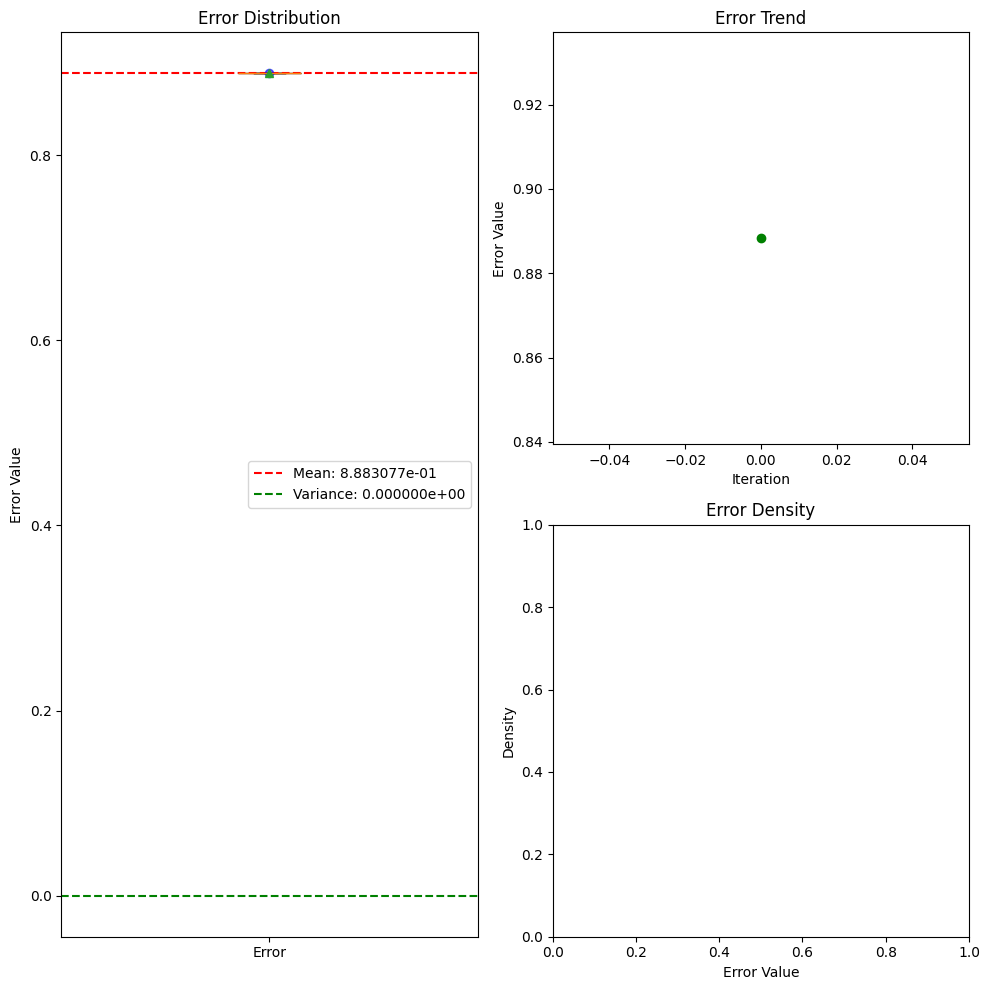

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns  # 导入seaborn库用于绘制密度图

# error = [0.5202765768338299, 0.5498189856925179, 0.8054262198745831, 0.2836623431751703, 0.7163985307835498, 0.8486951661259542, 0.45799139947295237, 1.0888879509613618, 0.18105234189218838, 0.5686642080465825]
error = error_u

plt.figure(figsize=(10, 10))  # 调整整体图表尺寸

# 左侧子图：箱形图，占据两张图的位置，箱的上下边界为上下四分位数，箱内的横线+三角点为中位数，虚线为均值
plt.subplot(1, 2, 1)  # 第一个子图，现在布局为1行2列
mean_error = np.mean(error)
var_error = np.var(error)
print('mean Error u: %e' % (mean_error)) #打印误差
print('Variance Error u: %e' % (var_error)) #打印方差


plt.subplot(1, 2, 1)
plt.boxplot(error, patch_artist=True, showmeans=True, meanline=False, boxprops=dict(facecolor='lightblue'))
plt.axhline(mean_error, color='r', linestyle='--', label=f'Mean: {mean_error:e}')
plt.axhline(var_error, color='g', linestyle='--', label=f'Variance: {var_error:e}')  # 添加方差的水平线
for i, value in enumerate(error):
    plt.plot(1, value, 'bo', alpha=0.6)
plt.title('Error Distribution')
plt.ylabel('Error Value')
plt.xticks([1], ['Error'])
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(error, '-o', color='green')
plt.title('Error Trend')
plt.ylabel('Error Value')
plt.xlabel('Iteration')

plt.subplot(2, 2, 4)
sns.kdeplot(error, shade=True, color="r", alpha=0.6)
plt.title('Error Density')
plt.xlabel('Error Value')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

In [ ]:
len_t = 101
len_x = 101

# --- 反向过程 (您需要的部分) ---

# 假设您现在只有 X_star, u_star，以及 len_t 和 len_x
# len_t = 101
# len_x = 256

# 1. 从 X_star 中分离出展平的 X 和 T
flat_X = X_star[:, 0]
flat_T = X_star[:, 1]

# 2. 使用 reshape 将它们恢复为原始的二维形状
# np.reshape 的默认顺序是 'C' (行主序)，这与 flatten 的默认行为一致
# 我们知道原始形状是 (len_t, len_x)
X = flat_X.reshape(len_t, len_x)
T = flat_T.reshape(len_t, len_x)

U_star = griddata(X_star, u_star.flatten(), (X, T), method='cubic')


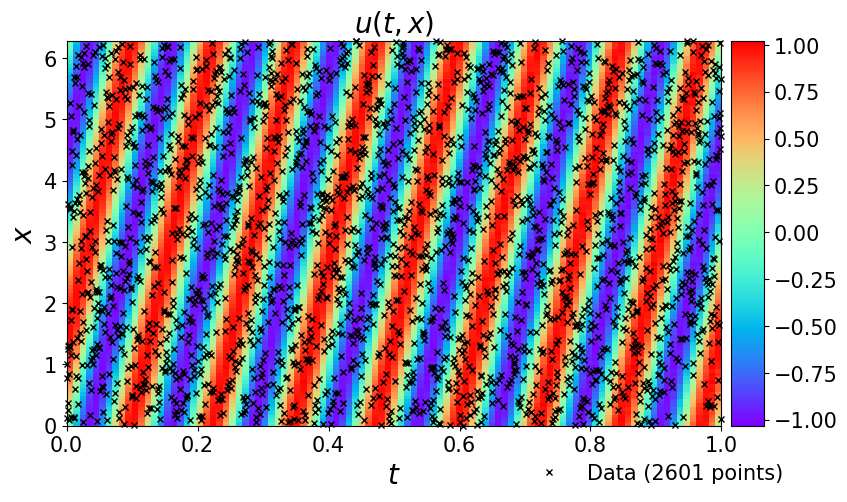

In [ ]:
###### Row 0: u(t,x) ##################    

fig = plt.figure(figsize=(9, 5)) #这里figure是一个figure对象，是一个图形窗口，代表整个图形，设置图形大小为宽9英寸高5 英寸
ax = fig.add_subplot(111) #在图形的1*1网格的第一个位置添加一个子图

#绘图的数据来源
im = ax.imshow(U_star.T, interpolation='nearest', cmap='rainbow', 
              extent=[lb[1], ub[1], lb[0], ub[0]], 
              origin='lower', aspect='auto')   #imshow函数用于显示图像，接受一些参数，第一个参数是图像数据，这里是U_pred的转置；第二个参数是插值方法（用于在像素之间插入新的像素），这里是最邻近插值；
                                                   #第三个参数是颜色映射，这里是用彩虹色图；第四个参数是图像的范围；第五个参数是图像的原点位置，这里表示原点在右下角；第六个参数是图像的纵横比，这里表示调整横纵比以填充整个axes对象
                                                   #最后的结果返回一个axesimage对象，也就是im，可以通过这个对象进一步设置图像的属性


#添加颜色条
divider = make_axes_locatable(ax)  #使用 make_axes_locatable 函数创建了一个 AxesDivider 对象。这个函数接受一个 Axes 对象作为参数，返回一个 AxesDivider 对象。AxesDivider 对象可以用来管理子图的布局，特别是当你需要在一个图的旁边添加另一个图时。
cax = divider.append_axes("right", size="5%", pad=0.10) #使用append_axes方法在原始轴的右侧添加了一个新的轴。append_axes 方法接受三个参数：位置（"right"）、大小（"5%"）和间距（0.10）。在原始轴的右侧添加了一个新的轴，新轴的大小是原始轴的 5%，新轴与原始轴之间的间距是 0.05 英寸
   
cbar = fig.colorbar(im, cax=cax)#使用colorbar方法在新轴上添加了一个颜色条。colorbar 方法接受两个参数：axesimage 对象（im）和新轴（cax）。并记这个颜色条的名字是cbar
cbar.ax.tick_params(labelsize=15) #设置颜色条刻度标签大小，这里bar是之前定义的


#在图上绘制散点图
ax.plot(
    X_f[:,1], 
    X_f[:,0], 
    'kx', label = 'Data (%d points)' % (X_f.shape[0]), 
    markersize = 4,  # marker size doubled
    clip_on = False,
    alpha=1.0
) #在ax上绘制散点图，前两个参数是散点的x坐标和y坐标；kx表示黑色的x（散点形状是x），label是散点的标签，clip_on表示散点可以绘制在轴的边界外
  #新加了一个alpha=1.0用来设置标记的透明度，1.0表示完全不透明  




#设置图的标签、图例、标题和刻度标签
#设置ax子图的x轴的标签为t，y轴的标签为x。这里$t$和$x$是latex格式的文本，用于生成数学公式
ax.set_xlabel('$t$', size=20)
ax.set_ylabel('$x$', size=20)
#设置子图ax的图例，第一个参数用来设置图例的位置，这里表示图例放在上方中央;第二个参数用来设置图例的锚点，接受一个元组，表示x和y坐标，表示把图例的锚点设置在x坐标为0.9，y坐标为-0.05处;frameon=False表示不显示图例的边框;第三个参数设置图例的列数，分为5列；最后一个参数设置图例属性，接受字典，这里表示设置图例字体大小为15；最后返回的leg是一个legend对象，表示图形的图例
ax.legend(
    loc='upper center', 
    bbox_to_anchor=(0.9, -0.05), 
    ncol=5, 
    frameon=False, 
    prop={'size': 15}
)
#设置子图ax的标题为$u(t,x)$，表示latex格式的文本，用于生成数学公式，fontsize=10表示字体大小为20
ax.set_title('$u(t,x)$', fontsize = 20) # font size doubled，两倍化子图标题
ax.tick_params(labelsize=15)#用来设置刻度标签的大小。`tick_params`是`Axes`对象的一个方法，可以用来设置刻度线的属性。在这里，`labelsize=15` 是用来设置刻度标签的字体大小的。


#显示图片
plt.show() #显示所有打开的图形的函数

In [ ]:
trainloss = torch.stack(model.loss_value).cpu().detach().numpy()


100


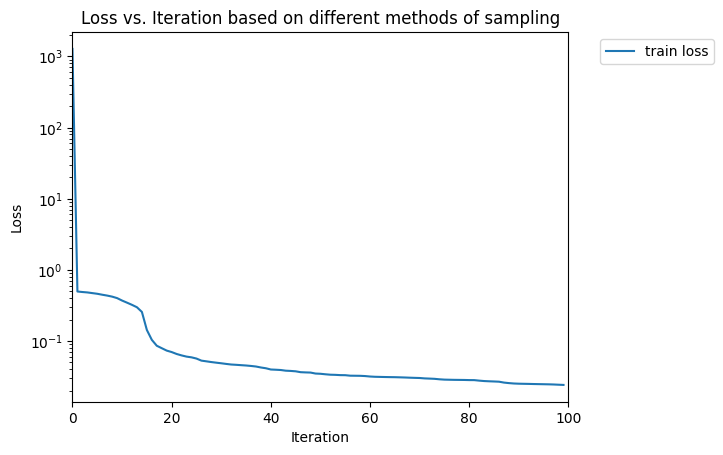

In [ ]:
print(len(trainloss))
# print(trainloss)
# 定义图例的标签
labels = ["Grid"]

# 创建一个新的图形
plt.figure()

# # 遍历所有的loss数据和标签
# for loss, label in zip(trainloss, labels):
#     # 绘制每个loss数据，并使用标签作为图例的条目
#     plt.plot(loss, label=label)

plt.plot(trainloss, label='train loss')

# 添加图例，放在图像外
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


plt.xlim([0,len(trainloss)]) # 设置x轴的范围
plt.yscale('log') #设置y轴为对数尺度，这样即使列表中有一些非常大的值，也不会影响其他值的可视化
plt.xlabel('Iteration') # 设置x轴的标签
plt.ylabel('Loss') # 设置y轴的标签
plt.title('Loss vs. Iteration based on different methods of sampling') # 设置图形的标题
# 显示图形
plt.show()
plt.show()

C:\Users\lcy\AppData\Local\Temp\ipykernel_94408\3375559269.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


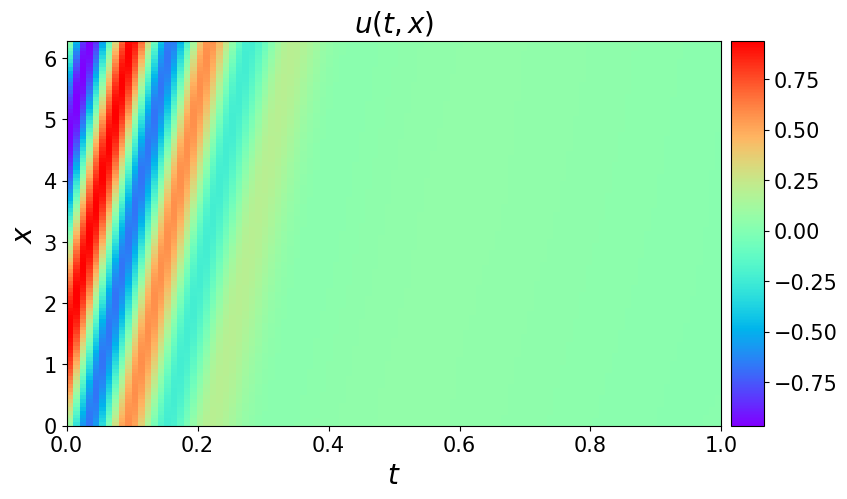

In [ ]:
#使用griddata函数将X_star、u_pred插值到网格上，得到U_pred
U_pred = griddata(X_star, u_pred.flatten(), (X, T), method='cubic')


###### Row 0: u(t,x) ##################    

fig = plt.figure(figsize=(9, 5)) #这里figure是一个figure对象，是一个图形窗口，代表整个图形，设置图形大小为宽9英寸高5 英寸
ax = fig.add_subplot(111) #在图形的1*1网格的第一个位置添加一个子图

#绘图的数据来源
im = ax.imshow(U_pred.T, interpolation='nearest', cmap='rainbow', 
              extent=[lb[1], ub[1], lb[0], ub[0]], 
              origin='lower', aspect='auto')   #imshow函数用于显示图像，接受一些参数，第一个参数是图像数据，这里是U_pred的转置；第二个参数是插值方法（用于在像素之间插入新的像素），这里是最邻近插值；


#添加颜色条
divider = make_axes_locatable(ax)  #使用 make_axes_locatable 函数创建了一个 AxesDivider 对象。这个函数接受一个 Axes 对象作为参数，返回一个 AxesDivider 对象。AxesDivider 对象可以用来管理子图的布局，特别是当你需要在一个图的旁边添加另一个图时。
cax = divider.append_axes("right", size="5%", pad=0.10) #使用append_axes方法在原始轴的右侧添加了一个新的轴。append_axes 方法接受三个参数：位置（"right"）、大小（"5%"）和间距（0.10）。在原始轴的右侧添加了一个新的轴，新轴的大小是原始轴的 5%，新轴与原始轴之间的间距是 0.05 英寸
   
cbar = fig.colorbar(im, cax=cax)#使用colorbar方法在新轴上添加了一个颜色条。colorbar 方法接受两个参数：axesimage 对象（im）和新轴（cax）。并记这个颜色条的名字是cbar
cbar.ax.tick_params(labelsize=15) #设置颜色条刻度标签大小，这里bar是之前定义的


# #在图上绘制散点图
# ax.plot(
#     X_f_train[:,1], 
#     X_f_train[:,0], 
#     'kx', label = 'Data (%d points)' % (X_f_train.shape[0]), 
#     markersize = 4,  # marker size doubled
#     clip_on = False,
#     alpha=1.0
# ) #在ax上绘制散点图，前两个参数是散点的x坐标和y坐标；kx表示黑色的x（散点形状是x），label是散点的标签，clip_on表示散点可以绘制在轴的边界外
#   #新加了一个alpha=1.0用来设置标记的透明度，1.0表示完全不透明  




#设置图的标签、图例、标题和刻度标签
#设置ax子图的x轴的标签为t，y轴的标签为x。这里$t$和$x$是latex格式的文本，用于生成数学公式
ax.set_xlabel('$t$', size=20)
ax.set_ylabel('$x$', size=20)
#设置子图ax的图例，第一个参数用来设置图例的位置，这里表示图例放在上方中央;第二个参数用来设置图例的锚点，接受一个元组，表示x和y坐标，表示把图例的锚点设置在x坐标为0.9，y坐标为-0.05处;frameon=False表示不显示图例的边框;第三个参数设置图例的列数，分为5列；最后一个参数设置图例属性，接受字典，这里表示设置图例字体大小为15；最后返回的leg是一个legend对象，表示图形的图例
ax.legend(
    loc='upper center', 
    bbox_to_anchor=(0.9, -0.05), 
    ncol=5, 
    frameon=False, 
    prop={'size': 15}
)
#设置子图ax的标题为$u(t,x)$，表示latex格式的文本，用于生成数学公式，fontsize=10表示字体大小为20
ax.set_title('$u(t,x)$', fontsize = 20) # font size doubled，两倍化子图标题
ax.tick_params(labelsize=15)#用来设置刻度标签的大小。`tick_params`是`Axes`对象的一个方法，可以用来设置刻度线的属性。在这里，`labelsize=15` 是用来设置刻度标签的字体大小的。


#显示图片
plt.show() #显示所有打开的图形的函数

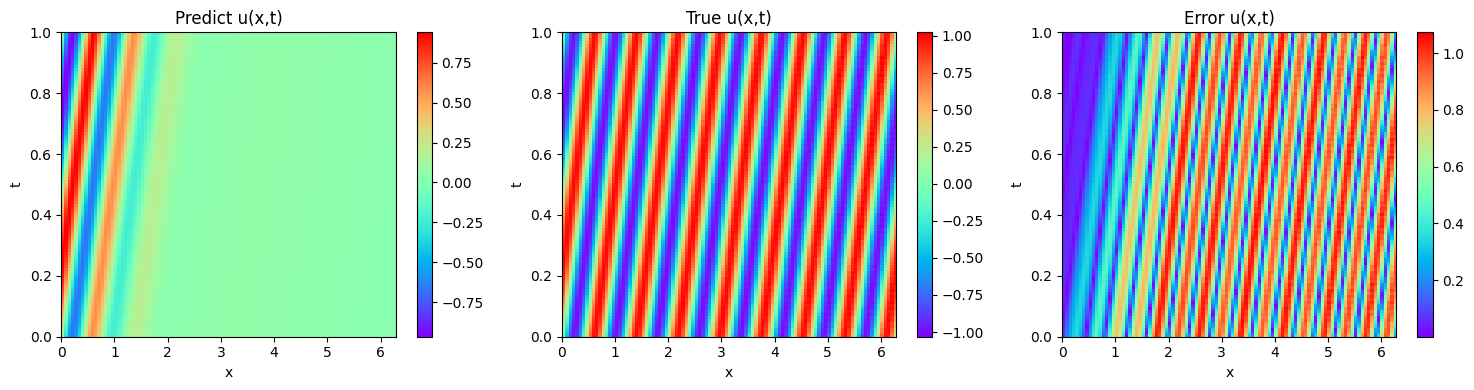

In [ ]:

# 创建一个包含三幅子图的图像
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 绘制第一幅图像
axes[0].imshow(U_pred.T, extent=[0, np.pi*2, 1, 0], aspect='auto', cmap='rainbow')
axes[0].invert_yaxis()
axes[0].set_xlabel('x')
axes[0].set_ylabel('t')
axes[0].set_title('Predict u(x,t)')
fig.colorbar(axes[0].images[0], ax=axes[0])

# 绘制第二幅图像
axes[1].imshow(U_star.T, extent=[0,np.pi*2,1,0], aspect='auto', cmap='rainbow') #第一个参数为数据，第二个参数为一个列表，用于设置图像的坐标范围，aspect='auto'表示纵横比自动调整
axes[1].invert_yaxis()
axes[1].set_xlabel('x')
axes[1].set_ylabel('t')
axes[1].set_title('True u(x,t)')
fig.colorbar(axes[1].images[0], ax=axes[1])

# 绘制第三幅图像
axes[2].imshow(np.abs(U_pred - U_star).T, extent=[0,np.pi*2,1,0], aspect='auto', cmap='rainbow') #第一个参数为数据，第二个参数为一个列表，用于设置图像的坐标范围，aspect='auto'表示纵横比自动调整
axes[2].invert_yaxis()
axes[2].set_xlabel('x')
axes[2].set_ylabel('t')
axes[2].set_title('Error u(x,t)')
fig.colorbar(axes[2].images[0], ax=axes[2])

# 自动调整子图参数，使得子图之间的间距适当
plt.tight_layout()
plt.show()